# **Project Name**    -

### End-to-End Customer Satisfaction Prediction and Business Intelligence System Using Machine Learning on Flipkart Customer Support Data

#### **Project Type**    - EDA + Classification
#### **Contribution**    - Individual
#### **Name -** Piyusha Shivade

# **Project Summary -**

This project focused on predicting customer satisfaction scores (CSAT Score) using the Flipkart Customer Support dataset. The objective was to analyze customer support interactions and build machine learning models capable of accurately predicting customer satisfaction levels.

The project began with data cleaning and preprocessing, including handling missing values, treating outliers, encoding categorical variables, and extracting useful features from date and time attributes. Feature selection and scaling techniques were then applied to prepare the data for machine learning.

Several machine learning models were developed and evaluated, including Random Forest, XGBoost, LightGBM, and a Stacking Classifier. Hyperparameter tuning was performed using RandomizedSearchCV to optimize model performance. The models were assessed using Accuracy, Precision, Recall, and F1 Score metrics.

Among all models, the Stacking Classifier achieved the best overall performance with an Accuracy of 69.64%, outperforming the individual models. The project demonstrates how machine learning can be applied to customer support data to identify satisfaction patterns, improve service quality, support business decision-making, and enhance customer experience.


# **GitHub Link -**

### https://github.com/PiyushaShivade

# **Problem Statement -**


The objective of this project is to predict customer satisfaction scores (CSAT Score) using customer support interaction data from Flipkart.

By analyzing factors such as product information, response time, customer location, issue reporting patterns, and support interactions, machine learning models are developed to identify customer satisfaction levels and provide actionable business insights.

Accurate prediction of customer satisfaction can help organizations improve service quality, customer retention, and operational efficiency.

## ***1. Know The Data***

### Import Libraries

In [1]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report,confusion_matrix,accuracy_score

import warnings
from sklearn.exceptions import UndefinedMetricWarning

warnings.filterwarnings('ignore')
warnings.filterwarnings('ignore', category=UndefinedMetricWarning)

### Dataset Loading

In [2]:
# Load Dataset
df = pd.read_csv('Customer_support_data.csv')
df.head()

,Unique id,channel_name,category,Sub-category,Customer Remarks,Order_id,order_date_time,Issue_reported at,issue_responded,Survey_response_Date,Customer_City,Product_category,Item_price,connected_handling_time,Agent_name,Supervisor,Manager,Tenure Bucket,Agent Shift,CSAT Score
0,7e9ae164-6a8b-4521-a2d4-58f7c9fff13f,Outcall,Product Queries,Life Insurance,NaN,c27c9bb4-fa36-4140-9f1f-21009254ffdb,NaN,01/08/2023 11:13,01/08/2023 11:47,01-Aug-23,NaN,NaN,NaN,NaN,Richard Buchanan,Mason Gupta,Jennifer Nguyen,On Job Training,Morning,5
1,b07ec1b0-f376-43b6-86df-ec03da3b2e16,Outcall,Product Queries,Product Specific Information,NaN,d406b0c7-ce17-4654-b9de-f08d421254bd,NaN,01/08/2023 12:52,01/08/2023 12:54,01-Aug-23,NaN,NaN,NaN,NaN,Vicki Collins,Dylan Kim,Michael Lee,>90,Morning,5
2,200814dd-27c7-4149-ba2b-bd3af3092880,Inbound,Order Related,Installation/demo,NaN,c273368d-b961-44cb-beaf-62d6fd6c00d5,NaN,01/08/2023 20:16,01/08/2023 20:38,01-Aug-23,NaN,NaN,NaN,NaN,Duane Norman,Jackson Park,William Kim,On Job Training,Evening,5
3,eb0d3e53-c1ca-42d3-8486-e42c8d622135,Inbound,Returns,Reverse Pickup Enquiry,NaN,5aed0059-55a4-4ec6-bb54-97942092020a,NaN,01/08/2023 20:56,01/08/2023 21:16,01-Aug-23,NaN,NaN,NaN,NaN,Patrick Flores,Olivia Wang,John Smith,>90,Evening,5
4,ba903143-1e54-406c-b969-46c52f92e5df,Inbound,Cancellation,Not Needed,NaN,e8bed5a9-6933-4aff-9dc6-ccefd7dcde59,NaN,01/08/2023 10:30,01/08/2023 10:32,01-Aug-23,NaN,NaN,NaN,NaN,Christopher Sanchez,Austin Johnson,Michael Lee,0-30,Morning,5


### Dataset First View

## Dataset First Look

The dataset contains customer support interactions from Flipkart. Each record represents a customer service case and includes information such as:

- Channel used for communication (Inbound, Outcall, Email)
- Issue category and sub-category
- Customer remarks
- Order information
- Product category and item price
- Agent details
- Response timestamps
- Customer Satisfaction (CSAT) Score

By examining the first few records, we can understand the structure of the dataset, identify the available features, and detect any obvious missing values or inconsistencies before performing further analysis.

### Dataset Rows & Columns count

In [3]:
# Dataset Rows & Columns count

print("Number of Rows:", df.shape[0])
print("Number of Columns:", df.shape[1])

Number of Rows: 85907
Number of Columns: 20


### Dataset Information

In [4]:
# Dataset Info

print("Dataset Information")
print("-" * 50)
df.info()

Dataset Information
--------------------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 85907 entries, 0 to 85906
Data columns (total 20 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Unique id                85907 non-null  object 
 1   channel_name             85907 non-null  object 
 2   category                 85907 non-null  object 
 3   Sub-category             85907 non-null  object 
 4   Customer Remarks         28742 non-null  object 
 5   Order_id                 67675 non-null  object 
 6   order_date_time          17214 non-null  object 
 7   Issue_reported at        85907 non-null  object 
 8   issue_responded          85907 non-null  object 
 9   Survey_response_Date     85907 non-null  object 
 10  Customer_City            17079 non-null  object 
 11  Product_category         17196 non-null  object 
 12  Item_price               17206 non-null  float64
 13  conne

# Dataset Info

The `info()` function provides a concise summary of the dataset, including:

- Total number of entries (rows)
- Column names
- Number of non-null values in each column
- Data types of each feature
- Memory usage of the dataset

This information helps identify:
- Missing values
- Categorical and numerical variables
- Columns requiring data type conversion
- Features that may need preprocessing before analysis and modeling

#### Duplicate Values

In [5]:
# Dataset Duplicate Value Count
duplicate_count = df.duplicated().sum()

print("Number of Duplicate Rows:", duplicate_count)

Number of Duplicate Rows: 0


#### Missing Values/Null Values

In [6]:
# Missing Values/Null Values Count

missing_df = pd.DataFrame({
    'Column Name': df.columns,
    'Missing Values': df.isnull().sum().values,
    'Percentage': (df.isnull().sum()/len(df)*100).values})

missing_df.sort_values(by='Missing Values', ascending=False)

,Column Name,Missing Values,Percentage
13,connected_handling_time,85665,99.718300
10,Customer_City,68828,80.119199
11,Product_category,68711,79.983005
12,Item_price,68701,79.971364
6,order_date_time,68693,79.962052
4,Customer Remarks,57165,66.542889
5,Order_id,18232,21.222950
0,Unique id,0,0.000000
3,Sub-category,0,0.000000
2,category,0,0.000000


# Missing Values/Null Values Count

Missing values occur when information is unavailable or not recorded for a particular observation.

Identifying missing values is important because:

- They can affect statistical analysis.
- They may reduce machine learning model performance.
- Some algorithms cannot handle missing values directly.
- Appropriate treatment such as imputation or removal may be required.

The `isnull()` function identifies missing values, while `sum()` counts the total number of missing observations in each feature.

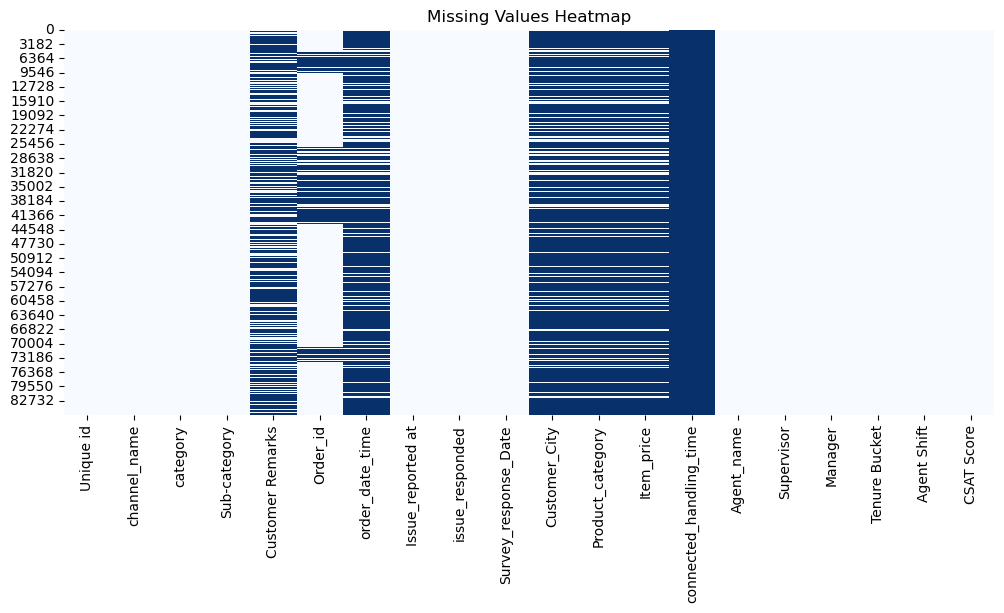

In [7]:
# Visualizing the missing values - Heatmap

plt.figure(figsize=(12,5))
sns.heatmap(df.isnull(), cbar=False, cmap='Blues')

plt.title('Missing Values Heatmap')
plt.show()

# Visualizing Missing Values

Visualizing missing values helps us understand the distribution and pattern of missing data across the dataset.

A heatmap is used because:

- It provides a quick overview of missing values in all columns.
- It helps identify columns with a large number of missing records.
- It reveals whether missing values occur randomly or follow a specific pattern.
- It supports better decisions regarding data cleaning and preprocessing.

Understanding the missing value pattern is important before applying imputation or removing records, as it helps maintain data quality and improve the reliability of analysis and machine learning models.

### What did you know about your dataset?

* The dataset contains Flipkart customer support interaction records.
* It includes information about support channels, issue categories, and customer remarks.
* The dataset contains product details, agent information, and response timestamps.
* Customer satisfaction is measured using the CSAT Score.
* Both categorical and numerical features are present in the dataset.
* The data can be used to analyze customer satisfaction, agent performance, and support efficiency.
* It is suitable for exploratory data analysis and machine learning model development.


## ***2. Understanding The Variables***

In [8]:
# Dataset Columns
df.columns

Index(['Unique id', 'channel_name', 'category', 'Sub-category',
       'Customer Remarks', 'Order_id', 'order_date_time', 'Issue_reported at',
       'issue_responded', 'Survey_response_Date', 'Customer_City',
       'Product_category', 'Item_price', 'connected_handling_time',
       'Agent_name', 'Supervisor', 'Manager', 'Tenure Bucket', 'Agent Shift',
       'CSAT Score'],
      dtype='object')

In [9]:
# Dataset Describe
df.describe()

,Item_price,connected_handling_time,CSAT Score
count,17206.000000,242.000000,85907.000000
mean,5660.774846,462.400826,4.242157
std,12825.728411,246.295037,1.378903
min,0.000000,0.000000,1.000000
25%,392.000000,293.000000,4.000000
50%,979.000000,427.000000,5.000000
75%,2699.750000,592.250000,5.000000
max,164999.000000,1986.000000,5.000000


### Variables Description

- Unique id: Unique identifier for each customer support interaction.
- channel_name: Communication channel used (Inbound, Outcall, Email).
- category: Main category of the customer issue.
- Sub-category: Specific issue type within a category.
- Customer Remarks: Feedback or comments provided by customers.
- Order_id: Unique order identifier.
- order_date_time: Date and time when the order was placed.
- Issue_reported at: Date and time when the issue was reported.
- issue_responded: Date and time when support responded.
- Survey_response_Date: Date when customer submitted the survey.
- Customer_City: Customer location.
- Product_category: Category of the purchased product.
- Item_price: Price of the product.
- connected_handling_time: Time spent handling the issue.
- Agent_name: Name of the support agent.
- Supervisor: Supervisor managing the agent.
- Manager: Manager overseeing the support team.
- Tenure Bucket: Agent experience level.
- Agent Shift: Working shift of the agent.
- CSAT Score: Customer Satisfaction Score (Target Variable).

### Check Unique Values for each variable.

In [10]:
# Check Unique Values for each variable.
for col in df.columns:
    print(f"\n{col}")
    print("Unique Values:", df[col].nunique())


Unique id
Unique Values: 85907

channel_name
Unique Values: 3

category
Unique Values: 12

Sub-category
Unique Values: 57

Customer Remarks
Unique Values: 18231

Order_id
Unique Values: 67675

order_date_time
Unique Values: 13766

Issue_reported at
Unique Values: 30923

issue_responded
Unique Values: 30262

Survey_response_Date
Unique Values: 31

Customer_City
Unique Values: 1782

Product_category
Unique Values: 9

Item_price
Unique Values: 2789

connected_handling_time
Unique Values: 211

Agent_name
Unique Values: 1371

Supervisor
Unique Values: 40

Manager
Unique Values: 6

Tenure Bucket
Unique Values: 5

Agent Shift
Unique Values: 5

CSAT Score
Unique Values: 5


## 3. ***Data Wrangling***

### Data Wrangling Code

In [11]:
# Create a copy of the dataset
df_clean = df.copy()

# Check dataset shape before cleaning
print("Dataset Shape Before Cleaning:", df_clean.shape)

# Remove duplicate rows
df_clean.drop_duplicates(inplace=True)

# Check dataset shape after removing duplicates
print("Dataset Shape After Removing Duplicates:", df_clean.shape)

# Convert date columns to datetime format
date_columns = [
    'order_date_time',
    'Issue_reported at',
    'issue_responded',
    'Survey_response_Date'
]

for col in date_columns:
    df_clean[col] = pd.to_datetime(df_clean[col], errors='coerce')

# Create Response Time feature (in minutes)
df_clean['Response_Time_Minutes'] = (
    df_clean['issue_responded'] -
    df_clean['Issue_reported at']
).dt.total_seconds() / 60

# Check missing values
print("\nMissing Values:")
print(df_clean.isnull().sum())

# Display data types
print("\nData Types:")
print(df_clean.dtypes)

# Display first 5 rows
print("\nCleaned Dataset Preview:")
display(df_clean.head())

# Response Time Statistics
print("\nResponse Time Statistics:")
print(df_clean['Response_Time_Minutes'].describe())

Dataset Shape Before Cleaning: (85907, 20)
Dataset Shape After Removing Duplicates: (85907, 20)

Missing Values:
Unique id                      0
channel_name                   0
category                       0
Sub-category                   0
Customer Remarks           57165
Order_id                   18232
order_date_time            68693
Issue_reported at          53933
issue_responded            54022
Survey_response_Date           0
Customer_City              68828
Product_category           68711
Item_price                 68701
connected_handling_time    85665
Agent_name                     0
Supervisor                     0
Manager                        0
Tenure Bucket                  0
Agent Shift                    0
CSAT Score                     0
Response_Time_Minutes      54274
dtype: int64

Data Types:
Unique id                          object
channel_name                       object
category                           object
Sub-category                       object


,Unique id,channel_name,category,Sub-category,Customer Remarks,Order_id,order_date_time,Issue_reported at,issue_responded,Survey_response_Date,...,Product_category,Item_price,connected_handling_time,Agent_name,Supervisor,Manager,Tenure Bucket,Agent Shift,CSAT Score,Response_Time_Minutes
0,7e9ae164-6a8b-4521-a2d4-58f7c9fff13f,Outcall,Product Queries,Life Insurance,NaN,c27c9bb4-fa36-4140-9f1f-21009254ffdb,NaT,2023-01-08 11:13:00,2023-01-08 11:47:00,2023-08-01,...,NaN,NaN,NaN,Richard Buchanan,Mason Gupta,Jennifer Nguyen,On Job Training,Morning,5,34.0
1,b07ec1b0-f376-43b6-86df-ec03da3b2e16,Outcall,Product Queries,Product Specific Information,NaN,d406b0c7-ce17-4654-b9de-f08d421254bd,NaT,2023-01-08 12:52:00,2023-01-08 12:54:00,2023-08-01,...,NaN,NaN,NaN,Vicki Collins,Dylan Kim,Michael Lee,>90,Morning,5,2.0
2,200814dd-27c7-4149-ba2b-bd3af3092880,Inbound,Order Related,Installation/demo,NaN,c273368d-b961-44cb-beaf-62d6fd6c00d5,NaT,2023-01-08 20:16:00,2023-01-08 20:38:00,2023-08-01,...,NaN,NaN,NaN,Duane Norman,Jackson Park,William Kim,On Job Training,Evening,5,22.0
3,eb0d3e53-c1ca-42d3-8486-e42c8d622135,Inbound,Returns,Reverse Pickup Enquiry,NaN,5aed0059-55a4-4ec6-bb54-97942092020a,NaT,2023-01-08 20:56:00,2023-01-08 21:16:00,2023-08-01,...,NaN,NaN,NaN,Patrick Flores,Olivia Wang,John Smith,>90,Evening,5,20.0
4,ba903143-1e54-406c-b969-46c52f92e5df,Inbound,Cancellation,Not Needed,NaN,e8bed5a9-6933-4aff-9dc6-ccefd7dcde59,NaT,2023-01-08 10:30:00,2023-01-08 10:32:00,2023-08-01,...,NaN,NaN,NaN,Christopher Sanchez,Austin Johnson,Michael Lee,0-30,Morning,5,2.0



Response Time Statistics:
count     31633.000000
mean       4647.152214
std       17113.187472
min           0.000000
25%           2.000000
50%           6.000000
75%          41.000000
max      177097.000000
Name: Response_Time_Minutes, dtype: float64


### What all manipulations have you done and insights you found?

### Data Wrangling Summary

- Created a copy of the original dataset to preserve raw data.
- Removed duplicate records to improve data quality.
- Converted date-related columns into datetime format.
- Created a new feature called `Response_Time_Minutes` to measure support response efficiency.
- Checked missing values and data types for further preprocessing.
- Prepared the dataset for exploratory data analysis and machine learning.

### Key Insights

- The dataset contains both categorical and numerical features.
- Several columns contain missing values that may require treatment.
- Response time is an important feature that can help explain customer satisfaction levels.
- Clean and properly formatted data improves the reliability of analysis and model performance.

## ***4. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables***

#### Chart 1: Customer Satisfaction Distribution


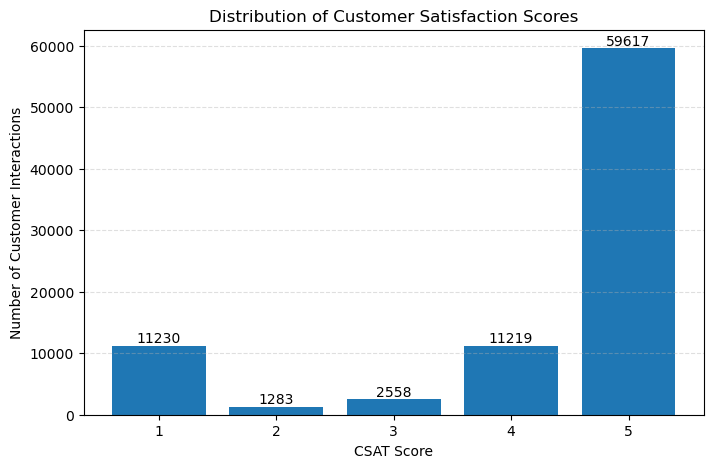

In [12]:
# Chart 1: Customer Satisfaction Distribution

csat_counts = (df_clean['CSAT Score'].value_counts().sort_index())

plt.figure(figsize=(8,5))

bars = plt.bar(csat_counts.index.astype(str), csat_counts.values)

# Add data labels
for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        int(bar.get_height()),
        ha='center',
        va='bottom')

plt.title('Distribution of Customer Satisfaction Scores')
plt.xlabel('CSAT Score')
plt.ylabel('Number of Customer Interactions')

plt.grid(axis='y', linestyle='--', alpha=0.4)

plt.show()

**Observation:**

The majority of customer ratings are concentrated around 5 and 4, indicating that most customers are satisfied with the support services provided. The significantly higher number of 5-star ratings reflects strong service performance and effective issue resolution. However, the presence of low ratings highlights areas where customer concerns may not have been fully addressed, creating opportunities to further enhance support quality and customer experience.

##### 1. Why did you pick the specific chart?

A bar chart was chosen because it provides a clear comparison of the frequency of each CSAT score. It helps understand the overall distribution of customer satisfaction ratings and quickly identifies the most common ratings given by customers.

##### 2. What is/are the insight(s) found from the chart?

- The chart shows how customer satisfaction scores are distributed across all support interactions.
- It helps identify whether customers are generally satisfied or dissatisfied with the support service.
- A higher concentration of ratings at the upper end indicates better customer experience, while lower ratings may highlight service quality issues.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive Impact:

Understanding customer satisfaction levels helps Flipkart monitor service quality and customer experience.
High CSAT scores indicate successful support operations and stronger customer loyalty.

Negative Impact:

A significant number of low CSAT ratings may indicate unresolved customer issues, poor communication, or delayed responses.
If these issues are not addressed, they can lead to customer dissatisfaction, negative reviews, and reduced customer retention.

#### Chart 2: Customer Issues by Category

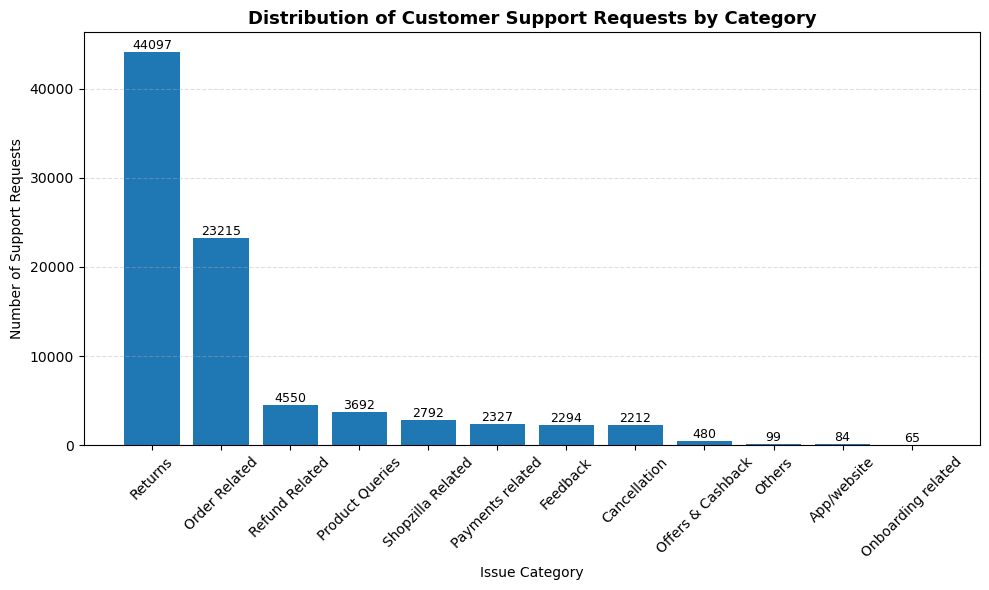

In [13]:
# Chart 2: Customer Issues by Category
category_counts = (df_clean.groupby('category').size().sort_values(ascending=False))

plt.figure(figsize=(10,6))

bars = plt.bar(category_counts.index, category_counts.values)

# Add value labels
for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f'{int(bar.get_height())}',
        ha='center',
        va='bottom',
        fontsize=9)

plt.title('Distribution of Customer Support Requests by Category', fontsize=13, fontweight='bold')

plt.xlabel('Issue Category')
plt.ylabel('Number of Support Requests')

plt.xticks(rotation=45)

plt.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

### Observation

The highest number of customer support requests belongs to the **Returns** category (44,097 requests), followed by **Order Related** issues (23,215 requests). This indicates that return processing and order management are the primary drivers of customer interactions. Categories such as Refund Related, Product Queries, and Cancellation generate comparatively fewer requests, while categories like App/Website issues and Onboarding Related contribute very little to the overall support volume. Improving return handling processes and order-related services can significantly reduce support workload and enhance customer satisfaction.

##### 1. Why did you pick the specific chart?

A bar chart was selected because it provides a clear comparison of customer support request volumes across different issue categories. It helps identify the categories that contribute the most to overall support workload.

##### 2. What is/are the insight(s) found from the chart?

- The chart identifies the most frequently reported customer issues.
- Certain categories generate significantly more support requests than others.
- High-volume categories indicate recurring customer concerns that may require operational improvements.
- Lower-volume categories may represent isolated or less frequent issues.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive Impact:

- Understanding the most common issue categories helps prioritize business improvements.
- Resources can be allocated more effectively to high-demand support areas.
- Resolving recurring issues can reduce support costs and improve customer satisfaction.

Negative Impact:

- Categories with exceptionally high complaint volumes may indicate underlying operational problems.
- Failure to address these recurring issues can increase customer dissatisfaction, return rates, and negative brand perception.

#### Chart 3: Top 10 Support Sub-Categories

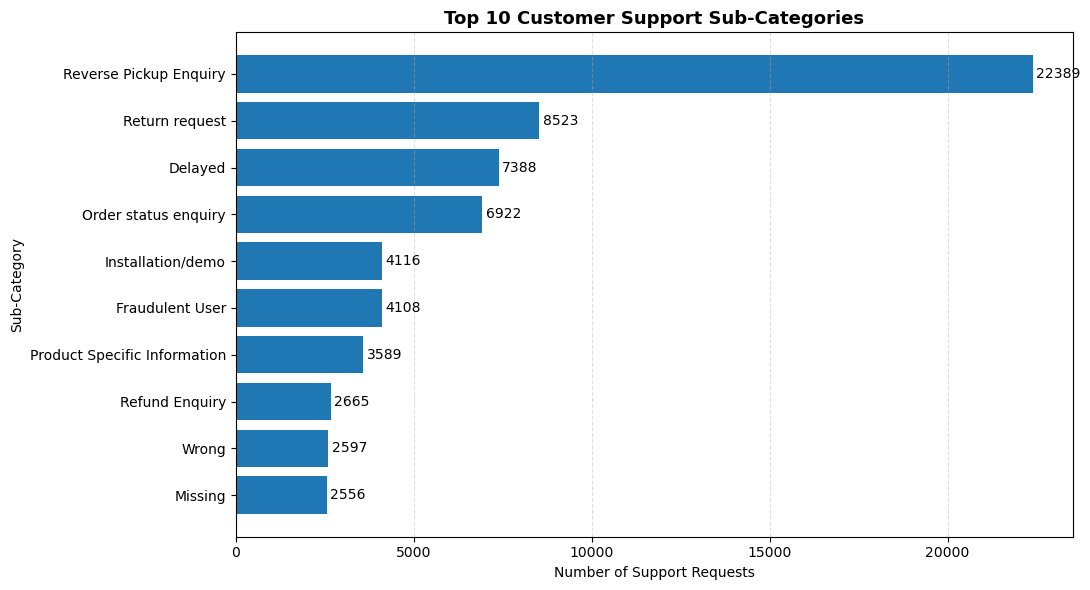

In [14]:
# Chart 3: Top 10 Support Sub-Categories

top_subcategories = (
    df_clean['Sub-category']
    .value_counts()
    .head(10)
    .sort_values()
)

plt.figure(figsize=(11,6))

bars = plt.barh(
    top_subcategories.index,
    top_subcategories.values
)

for bar in bars:
    plt.text(
        bar.get_width() + 100,
        bar.get_y() + bar.get_height()/2,
        f'{int(bar.get_width())}',
        va='center'
    )

plt.title(
    'Top 10 Customer Support Sub-Categories',
    fontsize=13,
    fontweight='bold'
)

plt.xlabel('Number of Support Requests')
plt.ylabel('Sub-Category')

plt.grid(
    axis='x',
    linestyle='--',
    alpha=0.4
)

plt.tight_layout()
plt.show()

### Observation

The analysis reveals that Reverse Pickup Enquiry is the dominant customer support issue, accounting for more than 22,000 requests. Return Requests, Delayed Deliveries, and Order Status Enquiries also contribute significantly to support volume. This indicates that customers primarily seek assistance after placing an order, particularly regarding returns, pickups, delivery delays, and order tracking. The findings suggest that improving post-purchase logistics and providing proactive order updates could substantially reduce customer support demand.

##### 1. Why did you pick the specific chart?

A horizontal bar chart was selected to identify the most common customer support sub-categories. While category analysis provides a broad overview, sub-category analysis helps uncover the exact issues customers face and provides deeper operational insights.

##### 2. What is/are the insight(s) found from the chart?

- Reverse Pickup Enquiry is the most common support issue with 22,389 requests, significantly higher than all other sub-categories.
- Return Request (8,523) and Delayed Orders (7,388) are the next most frequent customer concerns.
- Order Status Enquiry also contributes substantially to support workload with 6,922 requests.
- Most of the top issues are directly related to post-purchase logistics, returns, and order tracking.
- Product-related issues and refund enquiries occur less frequently compared to logistics-related concerns.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive Impact:

- The analysis helps identify the exact customer pain points within the support process.
- Improving reverse pickup operations, return handling, and delivery tracking can significantly reduce support requests.
- Providing proactive updates on order status and pickup schedules can improve customer satisfaction and operational efficiency.
- Reducing recurring support issues can lower customer service costs and enhance customer loyalty.

Negative Impact:

- The extremely high number of Reverse Pickup Enquiries indicates potential inefficiencies in the return and pickup process.
- Frequent Delayed Delivery and Order Status Enquiry requests suggest gaps in communication and logistics management.
- If these issues remain unresolved, customer frustration may increase, leading to lower CSAT scores, negative reviews, and reduced customer retention.
- High support volumes for the same issues can also increase operational costs and reduce overall service efficiency.

#### Chart - 4 Support Channel Distribution

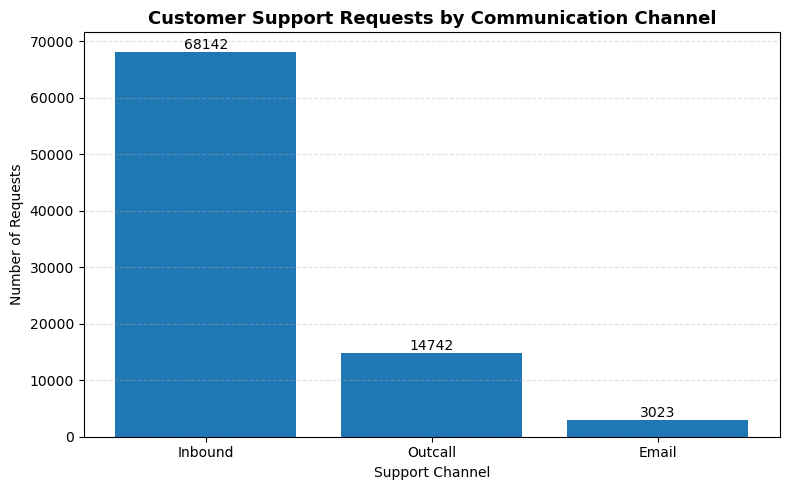

In [15]:
# Chart 4: Support Channel Distribution

channel_counts = (
    df_clean['channel_name']
    .value_counts()
    .sort_values(ascending=False)
)

plt.figure(figsize=(8,5))

bars = plt.bar(
    channel_counts.index,
    channel_counts.values
)

# Add value labels
for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        int(bar.get_height()),
        ha='center',
        va='bottom'
    )

plt.title(
    'Customer Support Requests by Communication Channel',
    fontsize=13,
    fontweight='bold'
)

plt.xlabel('Support Channel')
plt.ylabel('Number of Requests')

plt.grid(
    axis='y',
    linestyle='--',
    alpha=0.4
)

plt.tight_layout()
plt.show()

### Observation

The analysis shows that the Inbound channel is the primary mode of communication for customer support, handling more than 68,000 requests. Outcall support contributes a smaller proportion of interactions, while Email is used relatively infrequently. This suggests that customers prefer immediate and direct communication when resolving issues. The heavy reliance on the Inbound channel highlights the importance of maintaining sufficient staffing levels and efficient response mechanisms to ensure a positive customer experience.

##### 1. Why did you pick the specific chart?

A bar chart was selected because it provides a clear comparison of customer interactions across different communication channels. Understanding channel usage helps identify customer preferences and enables better resource allocation within the support team.

##### 2. What is/are the insight(s) found from the chart?

- The Inbound channel is the dominant communication channel, accounting for 68,142 customer support requests.
- Outcall interactions contribute 14,742 requests, significantly lower than Inbound support.
- Email is the least used channel, with only 3,023 requests.
- The results indicate that customers strongly prefer direct communication through inbound support channels when seeking assistance.
- The support workload is heavily concentrated in the Inbound channel.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive Impact

- Understanding channel preferences helps Flipkart allocate support resources more effectively.
- Investing in the Inbound support channel can improve response times and customer satisfaction.
- Optimizing high-demand channels can increase operational efficiency and reduce customer effort.
- Insights from channel usage can support better workforce planning and training strategies.

Negative Impact

- The heavy dependence on the Inbound channel may create operational bottlenecks during peak periods.
- High call volumes can increase waiting times and negatively affect customer satisfaction if staffing is insufficient.
- Underutilization of alternative channels such as Email may indicate missed opportunities for cost-effective support automation.
- Failure to balance channel workloads could increase operational costs and reduce service quality.

#### Chart - 5  Agent Shift Distribution

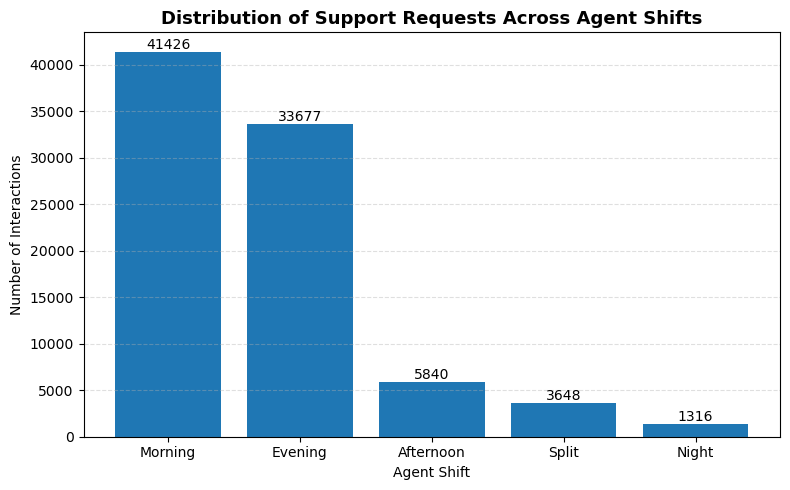

In [16]:
# Chart 5: Agent Shift Distribution

shift_counts = (
    df_clean['Agent Shift']
    .value_counts()
    .sort_values(ascending=False)
)

plt.figure(figsize=(8,5))

bars = plt.bar(
    shift_counts.index,
    shift_counts.values
)

# Add value labels
for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        int(bar.get_height()),
        ha='center',
        va='bottom'
    )

plt.title(
    'Distribution of Support Requests Across Agent Shifts',
    fontsize=13,
    fontweight='bold'
)

plt.xlabel('Agent Shift')
plt.ylabel('Number of Interactions')

plt.grid(
    axis='y',
    linestyle='--',
    alpha=0.4
)

plt.tight_layout()
plt.show()

### Observation

The Morning shift records the highest support workload, followed closely by the Evening shift. Together, these two shifts account for the majority of customer interactions, indicating that customer support demand is concentrated during standard business and post-work hours. In contrast, Afternoon, Split, and Night shifts handle considerably fewer requests. This suggests that workforce planning should prioritize staffing during Morning and Evening periods to maintain efficient service levels and customer satisfaction.

##### 1. Why did you pick the specific chart?

A bar chart was chosen because it clearly compares the volume of customer interactions handled during different agent shifts. Understanding shift distribution helps evaluate workforce allocation and operational efficiency.

##### 2. What is/are the insight(s) found from the chart?

- The Morning shift handles the highest number of customer interactions with 41,426 requests.
- The Evening shift is the second busiest period, handling 33,677 interactions.
- Afternoon, Split, and Night shifts manage significantly fewer requests compared to Morning and Evening shifts.
- More than 80% of customer support interactions are concentrated in the Morning and Evening shifts.
- Customer demand appears to be highest during daytime and early evening hours.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive Impact

- The analysis helps identify peak support periods and enables efficient workforce scheduling.
- Allocating more experienced agents during Morning and Evening shifts can improve response quality and customer satisfaction.
- Better staffing decisions can reduce customer waiting times and increase operational efficiency.
- Understanding workload patterns helps optimize resource utilization and support planning.

Negative Impact

- Insufficient staffing during Morning and Evening shifts may lead to longer waiting times and lower customer satisfaction.
- Overloading agents during peak periods can increase stress, reduce productivity, and affect service quality.
- Poor workforce planning may result in operational inefficiencies and higher support costs.
- If customer demand continues to grow without proper staffing adjustments, service performance may decline.

#### Chart - 6  Average CSAT Score by Communication Channel

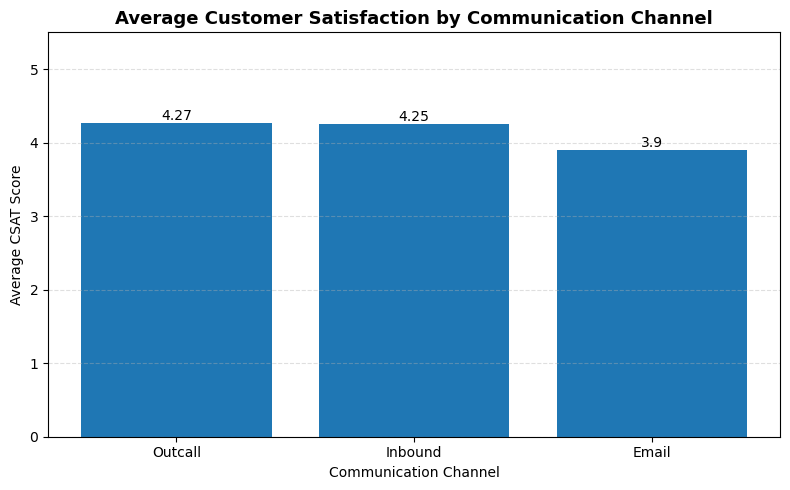

In [17]:
# Chart - 6 -- Bivariate Analysis --
# Chart 6: Average CSAT Score by Communication Channel

channel_csat = (
    df_clean
    .groupby('channel_name')['CSAT Score']
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(8,5))

bars = plt.bar(
    channel_csat.index,
    channel_csat.values
)

# Add average score labels
for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        round(bar.get_height(), 2),
        ha='center',
        va='bottom'
    )

plt.title(
    'Average Customer Satisfaction by Communication Channel',
    fontsize=13,
    fontweight='bold'
)

plt.xlabel('Communication Channel')
plt.ylabel('Average CSAT Score')

plt.ylim(0,5.5)

plt.grid(
    axis='y',
    linestyle='--',
    alpha=0.4
)

plt.tight_layout()
plt.show()

### Observation

The analysis reveals that Outcall support achieves the highest average customer satisfaction score of 4.27, closely followed by Inbound support at 4.25. In contrast, Email support records the lowest satisfaction score of 3.90. This suggests that direct and interactive communication channels provide a better customer experience than Email-based support. The findings indicate that personalized communication and quicker issue resolution may positively influence customer satisfaction levels.

##### 1. Why did you pick the specific chart?

A bar chart was selected to compare the average customer satisfaction score across different communication channels. This analysis helps determine which support channel provides the best customer experience and whether channel choice influences customer satisfaction.

##### 2. What is/are the insight(s) found from the chart?

- Outcall has the highest average CSAT score (4.27), indicating the best customer satisfaction among all communication channels.
- Inbound support also performs strongly with an average CSAT score of 4.25.
- Email has the lowest average CSAT score (3.90), suggesting comparatively lower customer satisfaction.
- The difference between Outcall and Inbound is minimal, indicating consistent service quality across direct communication channels.
- Customers appear to be more satisfied with interactive communication methods compared to Email support.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive Impact

- The analysis identifies the communication channels that deliver the best customer experience.
- Best practices from high-performing channels such as Outcall and Inbound can be applied across other channels.
- Improving channel-specific service quality can increase customer satisfaction and loyalty.
- Understanding channel performance supports better investment and resource allocation decisions.

Negative Impact

- The lower satisfaction score for Email support may indicate slower response times, limited interaction, or unresolved customer concerns.
- Poor customer experiences in Email support could negatively affect customer trust and overall service perception.
- If underperforming channels are not improved, they may contribute to increased customer dissatisfaction and reduced retention rates.
- Inconsistent service quality across channels can damage brand reputation and customer confidence.

#### Chart - 7  Average CSAT Score by Issue Category

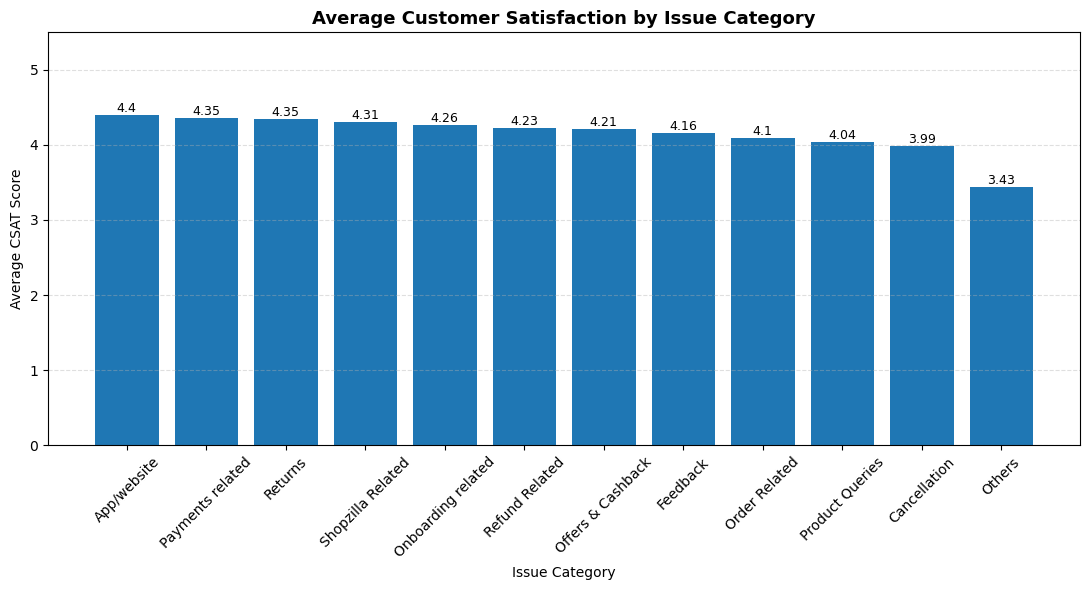

In [18]:
# Chart 7: Average CSAT Score by Issue Category

category_csat = (
    df_clean
    .groupby('category')['CSAT Score']
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(11,6))

bars = plt.bar(
    category_csat.index,
    category_csat.values
)

# Add average values
for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        round(bar.get_height(), 2),
        ha='center',
        va='bottom',
        fontsize=9
    )

plt.title(
    'Average Customer Satisfaction by Issue Category',
    fontsize=13,
    fontweight='bold'
)

plt.xlabel('Issue Category')
plt.ylabel('Average CSAT Score')

plt.xticks(rotation=45)

plt.ylim(0,5.5)

plt.grid(
    axis='y',
    linestyle='--',
    alpha=0.4
)

plt.tight_layout()
plt.show()

### Observation

The analysis reveals that App/Website issues generate the highest customer satisfaction score, followed closely by Payments Related and Returns categories. Most categories maintain average satisfaction scores above 4.0, indicating generally positive customer experiences. However, the "Others" category records a significantly lower satisfaction score of 3.43, suggesting that these cases may involve complex, uncommon, or unresolved issues. The findings indicate that while Flipkart performs well in handling standard support requests, additional attention may be required for less structured customer concerns.

##### 1. Why did you pick the specific chart?

A bar chart was selected to compare average customer satisfaction across different issue categories. This helps identify which types of customer issues are handled effectively and which categories may require process improvements to enhance customer experience.

##### 2. What is/are the insight(s) found from the chart?

- App/Website issues have the highest average CSAT score (4.40), indicating that these issues are generally resolved effectively.
- Payments Related and Returns categories also achieve high customer satisfaction scores (4.35), suggesting efficient handling of these requests.
- Order Related, Product Queries, and Cancellation categories have comparatively lower satisfaction scores.
- The "Others" category records the lowest average CSAT score (3.43), significantly below all other categories.
- The large gap between the highest and lowest categories indicates differences in issue complexity, resolution effectiveness, or customer expectations.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive Impact

- Identifies categories that consistently deliver high customer satisfaction.
- Best practices from high-performing categories can be replicated across other support areas.
- Helps management prioritize improvement efforts in lower-performing categories.
- Supports data-driven decision-making for customer experience enhancement.
- Improving low-performing categories can increase customer loyalty and retention.

Negative Impact

- The low satisfaction score in the "Others" category may indicate unresolved or complex customer issues.
- Lower-performing categories such as Cancellation and Product Queries may negatively influence customer perception if not improved.
- Poor experiences in specific categories can lead to repeat complaints, reduced trust, and lower customer retention.
- Failure to address dissatisfaction drivers may impact overall brand reputation and business growth.

#### Chart - 8  Average CSAT Score by Agent Tenure Bucket

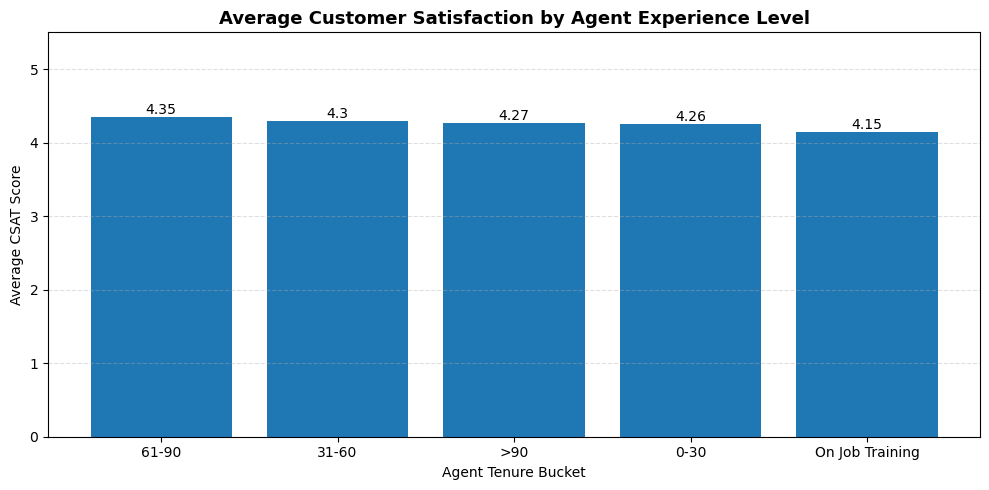

In [19]:
# Chart 8: Average CSAT Score by Agent Tenure Bucket

tenure_csat = (
    df_clean
    .groupby('Tenure Bucket')['CSAT Score']
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10,5))

bars = plt.bar(
    tenure_csat.index,
    tenure_csat.values
)

# Add average score labels
for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        round(bar.get_height(), 2),
        ha='center',
        va='bottom'
    )

plt.title(
    'Average Customer Satisfaction by Agent Experience Level',
    fontsize=13,
    fontweight='bold'
)

plt.xlabel('Agent Tenure Bucket')
plt.ylabel('Average CSAT Score')

plt.ylim(0,5.5)

plt.grid(
    axis='y',
    linestyle='--',
    alpha=0.4
)

plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A bar chart was chosen to compare average customer satisfaction scores across different agent experience levels. This analysis helps determine whether agent tenure influences service quality and customer satisfaction outcomes.

##### 2. What is/are the insight(s) found from the chart?

- Agents with 61–90 days of experience achieve the highest average CSAT score (4.35).
- Agents with 31–60 days and more than 90 days of experience also maintain high satisfaction scores above 4.25.
- Newly joined agents (0–30 days) perform reasonably well with an average CSAT score of 4.26.
- Agents undergoing On Job Training record the lowest satisfaction score (4.15).
- The difference between experience groups is relatively small, indicating a generally consistent level of service quality across the workforce.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive Impact

- The analysis demonstrates that agent experience has a positive influence on customer satisfaction.
- High-performing experienced agents can be used as mentors for newer employees.
- Training programs can be enhanced using best practices from experienced agents.
- Improved onboarding and coaching can help new agents achieve higher performance levels more quickly.
- Better workforce development can lead to improved customer satisfaction and service consistency.

Negative Impact

- Lower satisfaction scores among On Job Training agents may indicate skill gaps or limited experience in handling complex customer issues.
- If adequate training and mentoring are not provided, service quality may decline for customers interacting with new agents.
- Excessive dependence on experienced agents may create operational challenges if turnover increases.
- Poor onboarding processes could lead to inconsistent customer experiences and reduced customer loyalty.

#### Chart - 9  Response Time vs Customer Satisfaction

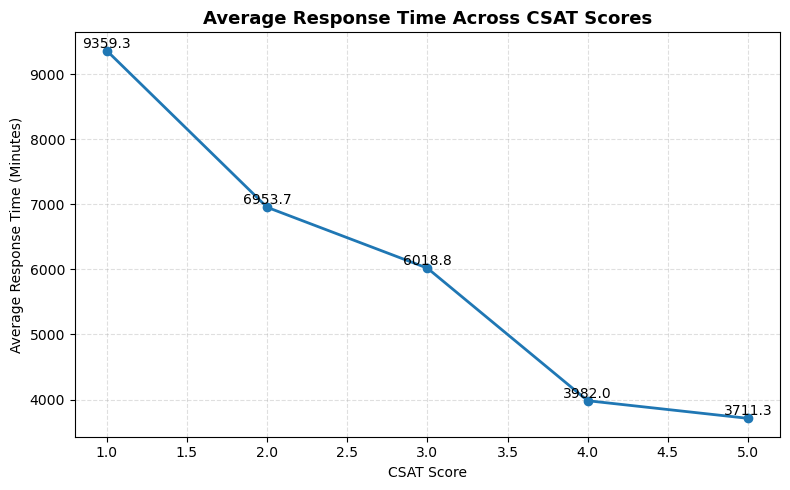

In [20]:
# Chart 9: Response Time vs Customer Satisfaction

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Remove missing values
chart_df = df_clean[['CSAT Score', 'Response_Time_Minutes']].copy()

chart_df['Response_Time_Minutes'] = pd.to_numeric(
    chart_df['Response_Time_Minutes'],
    errors='coerce'
)

chart_df = chart_df.dropna(subset=['CSAT Score', 'Response_Time_Minutes'])

# Calculate average response time for each CSAT score
response_csat = (
    chart_df
    .groupby('CSAT Score')['Response_Time_Minutes']
    .mean()
)

# Plot
plt.figure(figsize=(8,5))

plt.plot(
    response_csat.index,
    response_csat.values,
    marker='o',
    linewidth=2
)

# Data labels
for x, y in zip(response_csat.index, response_csat.values):
    if pd.notna(y) and np.isfinite(y):
        plt.text(
            x,
            y,
            f'{y:.1f}',
            ha='center',
            va='bottom'
        )

plt.title(
    'Average Response Time Across CSAT Scores',
    fontsize=13,
    fontweight='bold'
)

plt.xlabel('CSAT Score')
plt.ylabel('Average Response Time (Minutes)')

plt.grid(
    linestyle='--',
    alpha=0.4
)

plt.tight_layout()
plt.show()

### Observation

The analysis reveals a strong negative relationship between response time and customer satisfaction. Customers who experienced longer response times tended to provide lower satisfaction scores, while customers who received quicker responses reported significantly higher satisfaction levels. The average response time decreases steadily from 9,359 minutes for customers with a CSAT score of 1 to 3,711 minutes for customers with a CSAT score of 5. This suggests that response speed plays a critical role in shaping customer perceptions and overall service quality.

##### 1. Why did you pick the specific chart?

A line chart was selected because it clearly illustrates the relationship between customer satisfaction scores and average response times. This helps determine whether quicker responses contribute to better customer experiences.

##### 2. What is/are the insight(s) found from the chart?

- The chart shows a clear inverse relationship between response time and customer satisfaction.
- Customers who gave a CSAT score of 1 experienced the highest average response time of approximately 9,359 minutes.
- As customer satisfaction increases, the average response time decreases consistently.
- Customers who gave a CSAT score of 5 experienced the lowest average response time of approximately 3,711 minutes.
- The findings indicate that faster response times are strongly associated with higher customer satisfaction levels.
- Response time appears to be one of the most influential factors affecting customer experience.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive Impact

- The analysis clearly identifies response time as a key driver of customer satisfaction.
- Reducing response times can directly improve customer experience and satisfaction scores.
- Faster issue resolution can increase customer loyalty and retention.
- The findings provide actionable guidance for improving operational efficiency.
- Investing in workforce optimization and process automation can help achieve better service performance.

Negative Impact

- Excessive response times are strongly associated with lower customer satisfaction.
- Delays in customer support may increase frustration, complaints, and negative customer reviews.
- Poor response efficiency can reduce customer trust and increase churn risk.
- If response times continue to increase, customer satisfaction and brand reputation may decline significantly.
- Operational bottlenecks causing delays can increase support costs and reduce overall service effectiveness.

#### Chart - 10  Average CSAT Score by Product Category

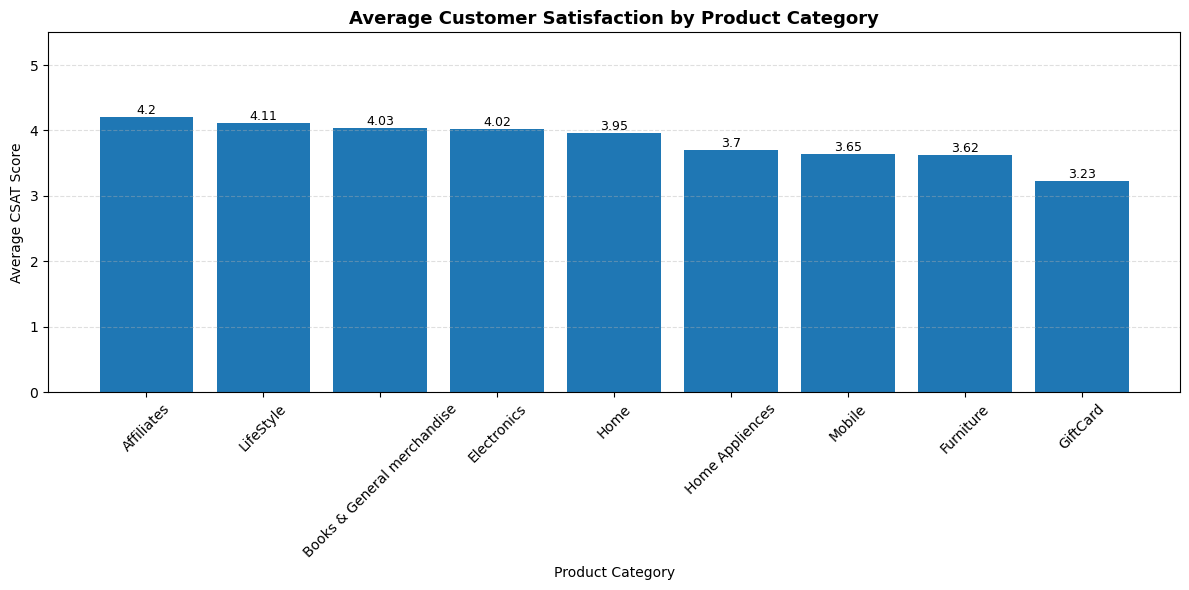

In [21]:
# Chart 10: Average CSAT Score by Product Category

product_csat = (
    df_clean
    .groupby('Product_category')['CSAT Score']
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(12,6))

bars = plt.bar(
    product_csat.index,
    product_csat.values
)

# Add value labels
for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        round(bar.get_height(), 2),
        ha='center',
        va='bottom',
        fontsize=9
    )

plt.title(
    'Average Customer Satisfaction by Product Category',
    fontsize=13,
    fontweight='bold'
)

plt.xlabel('Product Category')
plt.ylabel('Average CSAT Score')

plt.xticks(rotation=45)

plt.ylim(0,5.5)

plt.grid(
    axis='y',
    linestyle='--',
    alpha=0.4
)

plt.tight_layout()
plt.show()

### Observation

The analysis reveals that Affiliates and Lifestyle categories achieve the highest customer satisfaction scores, indicating positive customer experiences within these segments. Most product categories maintain average CSAT scores close to or above 4.0, reflecting generally satisfactory service levels. However, the GiftCard category records the lowest satisfaction score at 3.23, while Mobile, Furniture, and Home Appliances also perform below the overall average. These findings suggest that certain product categories may require targeted improvements in customer support, issue resolution, or service delivery to enhance customer satisfaction.

##### 1. Why did you pick the specific chart?

A bar chart was selected to compare customer satisfaction across different product categories. This analysis helps identify which product segments deliver better customer experiences and highlights categories that may require operational improvements or enhanced customer support.

##### 2. What is/are the insight(s) found from the chart?

- Affiliates achieve the highest average CSAT score (4.20), followed by Lifestyle (4.11).
- Books & General Merchandise and Electronics also maintain satisfaction scores above 4.0.
- Home Appliances, Mobile, and Furniture categories have comparatively lower satisfaction levels.
- GiftCard records the lowest average CSAT score (3.23), significantly below all other product categories.
- The variation in satisfaction across product categories suggests differences in customer expectations, product quality, support requirements, or service experiences.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive Impact

- Identifies product categories that consistently deliver strong customer experiences.
- Helps management replicate successful practices from high-performing categories.
- Enables targeted improvements for categories with lower satisfaction scores.
- Supports better allocation of customer support and operational resources.
- Can improve customer retention and increase repeat purchases within underperforming categories.

Negative Impact

- The low satisfaction score in the GiftCard category may indicate unresolved service issues or customer frustrations.
- Mobile, Furniture, and Home Appliances categories may require additional attention to improve customer experience.
- Poor customer experiences within specific product categories can lead to increased complaints, returns, and negative reviews.
- If low-performing categories are not improved, customer trust and long-term loyalty may decline.

#### Chart - 11 Average CSAT Score by Agent Shift

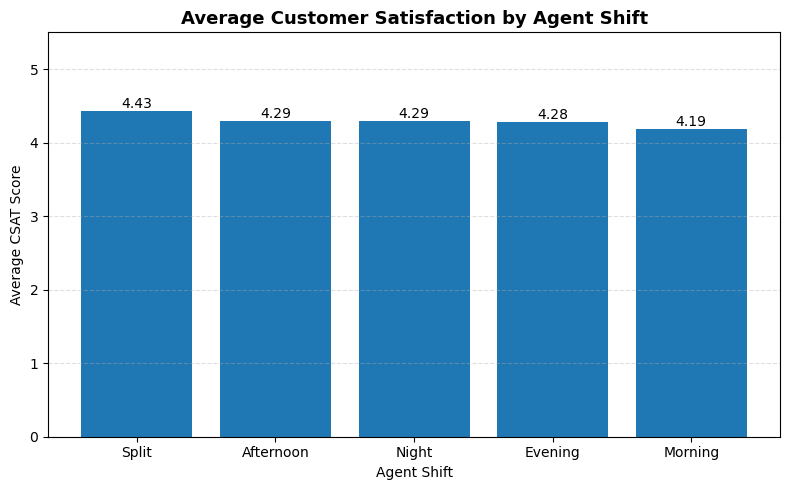

In [22]:
# Chart 11: Average CSAT Score by Agent Shift

shift_csat = (
    df_clean
    .groupby('Agent Shift')['CSAT Score']
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(8,5))

bars = plt.bar(
    shift_csat.index,
    shift_csat.values
)

# Add labels
for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        round(bar.get_height(), 2),
        ha='center',
        va='bottom'
    )

plt.title(
    'Average Customer Satisfaction by Agent Shift',
    fontsize=13,
    fontweight='bold'
)

plt.xlabel('Agent Shift')
plt.ylabel('Average CSAT Score')

plt.ylim(0,5.5)

plt.grid(
    axis='y',
    linestyle='--',
    alpha=0.4
)

plt.tight_layout()
plt.show()

### Observation

The analysis shows that the Split shift achieves the highest customer satisfaction score, while the Morning shift records the lowest average satisfaction level. Although the differences are relatively small, an important finding is that the Morning shift handles the highest workload but delivers slightly lower customer satisfaction. This may indicate the impact of higher customer volumes, increased workload pressure, or longer response times during peak operating hours. Overall, service quality remains consistently high across all shifts.

##### 1. Why did you pick the specific chart?

A bar chart was selected to compare customer satisfaction across different agent shifts. This analysis helps determine whether service quality varies by shift and whether staffing or workload factors influence customer experience.

##### 2. What is/are the insight(s) found from the chart?

- The Split shift achieves the highest average CSAT score (4.43), indicating the best customer satisfaction performance among all shifts.
- Afternoon and Night shifts perform similarly, both maintaining strong satisfaction scores of 4.29.
- Evening shift also performs well with an average CSAT score of 4.28.
- Morning shift records the lowest average CSAT score (4.19), despite handling the highest volume of customer interactions.
- The relatively small variation between shifts suggests that service quality is generally consistent across the organization.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive Impact

- Identifies high-performing shifts and operational practices that can be replicated across other shifts.
- Helps management optimize staffing strategies during peak demand periods.
- Supports continuous improvement initiatives aimed at enhancing customer experience.
- Enables better workload balancing and workforce planning.
- Can improve overall service consistency and customer satisfaction.

Negative Impact

- The lower CSAT score observed during the Morning shift may indicate workload-related challenges.
- High interaction volumes during peak periods could reduce service quality if staffing levels are insufficient.
- Increased agent workload may contribute to slower response times and reduced customer satisfaction.
- Failure to address peak-hour operational pressures may negatively affect customer experience and retention.

#### Chart - 12 Top 10 Supervisors by Average CSAT Score

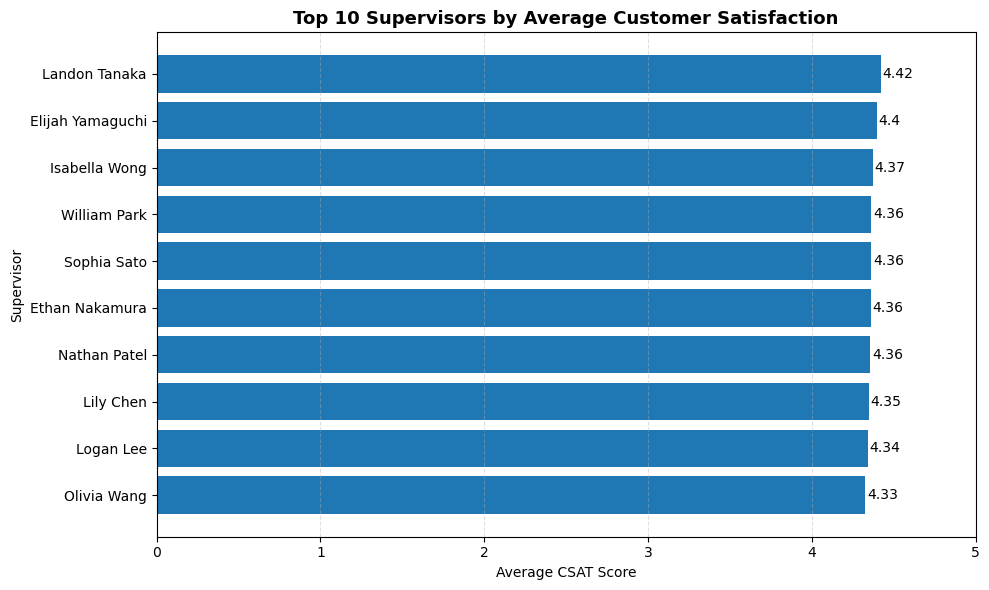

In [23]:
# Chart 12: Top 10 Supervisors by Average CSAT Score

top_supervisors = (
    df_clean
    .groupby('Supervisor')['CSAT Score']
    .mean()
    .sort_values(ascending=False)
    .head(10)
    .sort_values()
)

plt.figure(figsize=(10,6))

bars = plt.barh(
    top_supervisors.index,
    top_supervisors.values
)

# Value labels
for bar in bars:
    plt.text(
        bar.get_width() + 0.01,
        bar.get_y() + bar.get_height()/2,
        round(bar.get_width(),2),
        va='center'
    )

plt.title(
    'Top 10 Supervisors by Average Customer Satisfaction',
    fontsize=13,
    fontweight='bold'
)

plt.xlabel('Average CSAT Score')
plt.ylabel('Supervisor')

plt.xlim(0,5)

plt.grid(
    axis='x',
    linestyle='--',
    alpha=0.4
)

plt.tight_layout()
plt.show()

### Observation

The analysis reveals that Landon Tanaka leads the highest-performing team with an average customer satisfaction score of 4.42, closely followed by Elijah Yamaguchi and Isabella Wong. All supervisors in the top 10 maintain satisfaction scores above 4.30, demonstrating consistently strong customer service performance. The narrow performance gap among the leading supervisors suggests that effective leadership, team management, and operational practices are being successfully implemented across these teams. These supervisors can serve as benchmarks for best practices throughout the organization.

##### 1. Why did you pick the specific chart?

A horizontal bar chart was selected because it effectively ranks supervisors based on average customer satisfaction scores. This helps identify high-performing leaders whose teams consistently deliver positive customer experiences.

##### 2. What is/are the insight(s) found from the chart?

- Landon Tanaka achieves the highest average CSAT score (4.42), making them the top-performing supervisor.
- Elijah Yamaguchi follows closely with an average CSAT score of 4.40.
- All top 10 supervisors maintain CSAT scores above 4.30, indicating consistently strong team performance.
- The difference between the highest and lowest supervisor in the top 10 is relatively small, suggesting effective leadership practices across high-performing teams.
- High-performing supervisors may be applying successful coaching, workload management, and customer service strategies that contribute to superior customer experiences.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive Impact

- Identifies supervisors whose teams consistently deliver excellent customer experiences.
- Enables management to study and replicate successful leadership practices.
- Supports mentoring and knowledge-sharing programs across teams.
- Encourages performance benchmarking and continuous improvement.
- Can improve overall customer satisfaction through stronger leadership development initiatives.

Negative Impact

- Performance differences between supervisors may indicate inconsistencies in leadership effectiveness.
- Teams not following best practices may deliver lower customer satisfaction.
- Failure to transfer successful management strategies across teams may limit overall organizational performance.
- Leadership gaps can contribute to inconsistent customer experiences and operational inefficiencies.

#### Chart - 13  Bottom 10 Supervisors by Average CSAT Score

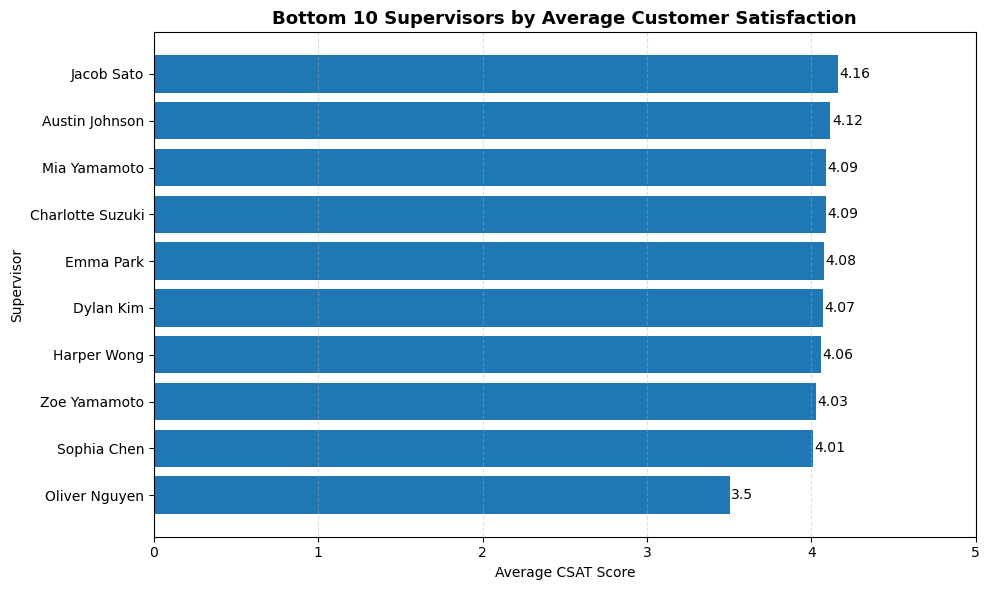

In [24]:
# Chart 13: Bottom 10 Supervisors by Average CSAT Score

bottom_supervisors = (
    df_clean
    .groupby('Supervisor')['CSAT Score']
    .mean()
    .sort_values(ascending=True)
    .head(10)
)

plt.figure(figsize=(10,6))

bars = plt.barh(
    bottom_supervisors.index,
    bottom_supervisors.values
)

# Add labels
for bar in bars:
    plt.text(
        bar.get_width() + 0.01,
        bar.get_y() + bar.get_height()/2,
        round(bar.get_width(),2),
        va='center'
    )

plt.title(
    'Bottom 10 Supervisors by Average Customer Satisfaction',
    fontsize=13,
    fontweight='bold'
)

plt.xlabel('Average CSAT Score')
plt.ylabel('Supervisor')

plt.xlim(0,5)

plt.grid(
    axis='x',
    linestyle='--',
    alpha=0.4
)

plt.tight_layout()
plt.show()

### Observation

The analysis reveals that Oliver Nguyen's team records the lowest customer satisfaction score at 3.50, considerably lower than the other supervisors in the bottom 10 group. While most supervisors maintain satisfaction levels above 4.00, the noticeable performance gap suggests that certain teams may be facing operational or management challenges. Comparing these results with the top-performing supervisors highlights opportunities to improve leadership effectiveness, team coaching, and customer service consistency across the organization.

##### 1. Why did you pick the specific chart?

A horizontal bar chart was selected because it clearly ranks supervisors with the lowest customer satisfaction scores. This helps identify teams that may benefit from additional coaching, training, or process improvements to enhance customer experience.

##### 2. What is/are the insight(s) found from the chart?

- Oliver Nguyen records the lowest average CSAT score (3.50), significantly below the other supervisors.
- Sophia Chen and Zoe Yamamoto also rank among the lowest-performing supervisors with average CSAT scores close to 4.00.
- Most supervisors in the bottom 10 maintain satisfaction scores between 4.00 and 4.16, indicating generally acceptable performance.
- The large gap between Oliver Nguyen and the remaining supervisors suggests a potential team-specific challenge requiring further investigation.
- Differences in supervisor performance may be influenced by workload, team experience, issue complexity, or management practices.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive Impact

- Helps identify supervisory teams requiring additional support and performance improvement.
- Enables targeted coaching, mentoring, and training interventions.
- Supports knowledge transfer from top-performing supervisors to lower-performing teams.
- Can improve customer satisfaction by reducing performance disparities across teams.
- Encourages a culture of continuous improvement and accountability.

Negative Impact

- Low-performing supervisory teams may deliver inconsistent customer experiences.
- Significant performance gaps can negatively affect overall service quality.
- Poor team management may contribute to slower issue resolution and lower customer satisfaction.
- If performance issues remain unresolved, customer complaints and dissatisfaction may increase.
- Persistent underperformance can negatively impact brand reputation and customer retention.

#### Chart - 14 - Correlation Heatmap

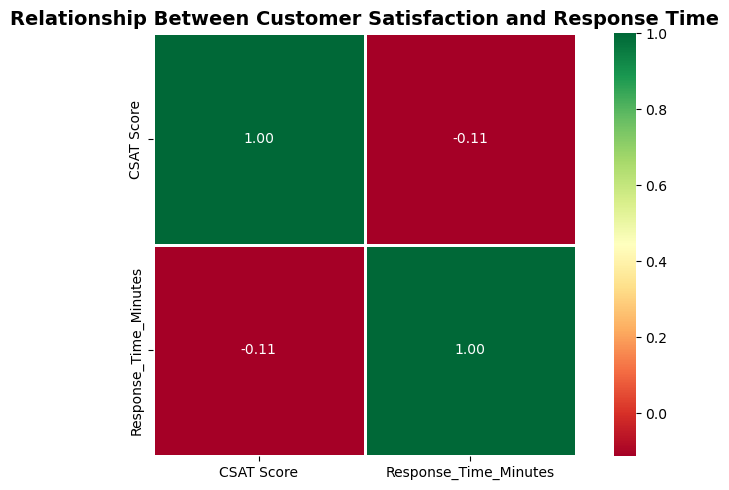

In [25]:
# Chart 14 - Correlation Heatmap

import seaborn as sns
import matplotlib.pyplot as plt

# Select numerical columns
numeric_features = [
    'CSAT Score',
    'Response_Time_Minutes'
]

# Correlation Matrix
corr_matrix = df_clean[numeric_features].corr()

# Plot
plt.figure(figsize=(8,5))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='RdYlGn',
    fmt='.2f',
    linewidths=1,
    square=True
)

plt.title(
    'Relationship Between Customer Satisfaction and Response Time',
    fontsize=14,
    fontweight='bold'
)

plt.tight_layout()
plt.show()

### Observation

The heatmap shows a weak negative correlation (-0.11) between Response Time and CSAT Score. This suggests that customers generally provide lower satisfaction ratings when they experience longer waiting times. However, because the relationship is relatively weak, customer satisfaction is not determined solely by response speed. Other operational factors such as issue resolution quality, communication channel effectiveness, agent experience, and supervisor performance also contribute to overall customer satisfaction.

##### 1. Why did you pick the specific chart?

After analysing customer issues, communication channels, agent shifts, and supervisor performance, it is important to statistically validate whether operational factors influence customer satisfaction. A correlation heatmap provides a simple and effective way to identify relationships between numerical variables and verify patterns observed throughout the analysis.

##### 2. What is/are the insight(s) found from the chart?

- The correlation between Response Time and CSAT Score is -0.11, indicating a weak negative relationship.
- As response time increases, customer satisfaction tends to decrease slightly.
- Although the relationship is not very strong, it confirms that faster responses generally contribute to better customer experiences.
- Customer satisfaction is influenced by response time, but other factors such as issue category, agent performance, communication channel, and supervisor effectiveness also play important roles.
- The result supports previous findings where customers receiving quicker support interactions reported higher satisfaction levels.

#### Chart - 15 - Scatter Plot with Trend Line

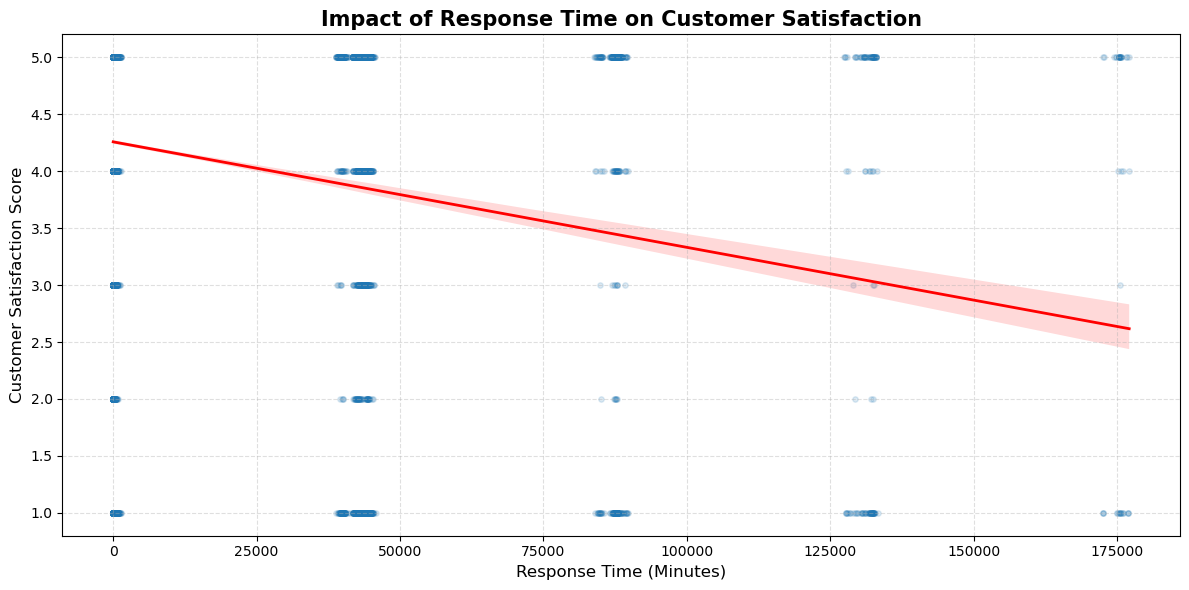

In [26]:
# Chart 15 - Scatter Plot with Trend Line

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,6))

sns.regplot(
    data=df_clean,
    x='Response_Time_Minutes',
    y='CSAT Score',
    scatter_kws={
        'alpha':0.15,
        's':15
    },
    line_kws={
        'color':'red',
        'linewidth':2
    }
)

plt.title(
    'Impact of Response Time on Customer Satisfaction',
    fontsize=15,
    fontweight='bold'
)

plt.xlabel('Response Time (Minutes)', fontsize=12)
plt.ylabel('Customer Satisfaction Score', fontsize=12)

plt.grid(
    linestyle='--',
    alpha=0.4
)

plt.tight_layout()
plt.show()

### Observation

The scatter plot reveals a downward trend between response time and customer satisfaction. Customers receiving quicker responses generally report higher satisfaction scores, while longer waiting times are associated with lower ratings. Although customer satisfaction is influenced by multiple operational factors, response efficiency clearly plays a significant role in shaping the overall customer experience.

##### 1. Why did you pick the specific chart?

After analysing customer issues, communication channels, agent shifts, supervisor performance, and response times, this chart was selected to directly examine the relationship between response efficiency and customer satisfaction. A scatter plot with a regression trend line provides a clear visual representation of how response delays may influence customer experience.

##### 2. What is/are the insight(s) found from the chart?

- The regression trend line shows a clear negative relationship between Response Time and CSAT Score.
- Customer satisfaction tends to decrease as response times become longer.
- Interactions with faster response times are generally associated with higher satisfaction ratings.
- Although some customers remain satisfied despite longer waiting periods, the overall trend indicates that timely support contributes to a better customer experience.
- The chart validates the correlation analysis and confirms that response efficiency is an important driver of customer satisfaction.

### Overall EDA Summary

The analysis identified key drivers of customer satisfaction, including response time, issue category, communication channel, agent performance, and supervisor effectiveness. Returns and order-related issues generated the highest support demand, while faster response times were associated with higher customer satisfaction. These findings provide valuable insights for improving customer experience and support operations.

## ***5. Hypothesis Testing***

### Based on your chart experiments, define three hypothetical statements from the dataset. In the next three questions, perform hypothesis testing to obtain final conclusion about the statements through your code and statistical testing.

**Hypothetical Statement 1**
Response time has a significant relationship with customer satisfaction scores.

**Hypothetical Statement 2**
Customer satisfaction scores differ significantly across issue categories.

**Hypothetical Statement 3**
Customer satisfaction scores differ significantly across agent experience levels.

### Hypothetical Statement - 1

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

**Null Hypothesis (H₀)**

There is no significant relationship between response time and customer satisfaction.

**Alternative Hypothesis (H₁)**

There is a significant relationship between response time and customer satisfaction.

#### 2. Perform an appropriate statistical test.

In [27]:
# Hypothesis Statement 1
# Does handling time significantly affect customer satisfaction?

from scipy.stats import pearsonr
import pandas as pd

# Convert handling time to numeric if needed
df['connected_handling_time'] = pd.to_numeric(
    df['connected_handling_time'],
    errors='coerce'
)

# Create clean dataframe
temp_df = df[['connected_handling_time', 'CSAT Score']].dropna()

# Pearson Correlation Test
corr_coef, p_value = pearsonr(
    temp_df['connected_handling_time'],
    temp_df['CSAT Score']
)

print("Correlation Coefficient:", round(corr_coef, 4))
print("P-Value:", p_value)

# Statistical Decision
alpha = 0.05

if p_value < alpha:
    print("\nDecision: Reject the Null Hypothesis (H₀)")
    print("Conclusion: Handling time has a statistically significant relationship with customer satisfaction.")
else:
    print("\nDecision: Fail to Reject the Null Hypothesis (H₀)")
    print("Conclusion: Handling time does not have a statistically significant relationship with customer satisfaction.")

Correlation Coefficient: 0.0475
P-Value: 0.4617820990375862

Decision: Fail to Reject the Null Hypothesis (H₀)
Conclusion: Handling time does not have a statistically significant relationship with customer satisfaction.


##### Which statistical test have you done to obtain P-Value?

Pearson Correlation Test

##### Why did you choose the specific statistical test?

Pearson Correlation Test was selected because both Connected Handling Time and Customer Satisfaction Score are numerical variables. The test measures the strength, direction, and statistical significance of the relationship between these variables.

### Conclusion

The Pearson Correlation Test produced a p-value of 0.4618, which is greater than the significance level of 0.05. Therefore, we fail to reject the null hypothesis. The analysis suggests that connected handling time does not have a statistically significant relationship with customer satisfaction scores in this dataset.

### Hypothetical Statement - 2

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

**Null Hypothesis (H₀)**

Customer satisfaction scores are the same across all issue categories.

**Alternative Hypothesis (H₁)**

Customer satisfaction scores differ across issue categories.

#### 2. Perform an appropriate statistical test.

In [28]:
# Perform Statistical Test to obtain P-Value
from scipy.stats import f_oneway

# Create groups for each issue category
groups = [
    group['CSAT Score'].dropna().values
    for _, group in df.groupby('category')
]

# One-Way ANOVA Test
f_stat, p_value = f_oneway(*groups)

print("F Statistic:", round(f_stat,4))
print("P Value:", p_value)

alpha = 0.05

if p_value < alpha:
    print("\nDecision: Reject the Null Hypothesis (H₀)")
    print("Conclusion: Customer satisfaction differs significantly across issue categories.")
else:
    print("\nDecision: Fail to Reject the Null Hypothesis (H₀)")
    print("Conclusion: Customer satisfaction does not differ significantly across issue categories.")

F Statistic: 67.0687
P Value: 2.0102219401078283e-150

Decision: Reject the Null Hypothesis (H₀)
Conclusion: Customer satisfaction differs significantly across issue categories.


##### Which statistical test have you done to obtain P-Value?

One-Way ANOVA Test

##### Why did you choose the specific statistical test?

One-Way ANOVA was selected because customer satisfaction scores are being compared across multiple issue categories. The test determines whether the mean CSAT score differs significantly among the categories.

### Conclusion

The One-Way ANOVA Test produced a p-value of 2.01e-150, which is significantly lower than 0.05. Therefore, the null hypothesis is rejected. This indicates that customer satisfaction scores vary significantly across issue categories. Some issue types result in better customer experiences than others and should be prioritized for service improvement.

### Hypothetical Statement - 3

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

**Research Statement**

Customer satisfaction scores differ significantly across agent experience levels.

**Null Hypothesis (H₀)**

There is no significant difference in customer satisfaction scores across agent experience levels.

**Alternative Hypothesis (H₁)**

There is a significant difference in customer satisfaction scores across agent experience levels.

#### 2. Perform an appropriate statistical test.

In [29]:
# Perform Statistical Test to obtain P-Value
from scipy.stats import f_oneway

# Create groups for each experience level
groups = [
    group['CSAT Score'].dropna().values
    for _, group in df.groupby('Tenure Bucket')
]

# One-Way ANOVA
f_stat, p_value = f_oneway(*groups)

print("F Statistic:", round(f_stat,4))
print("P Value:", p_value)

alpha = 0.05

if p_value < alpha:
    print("\nDecision: Reject the Null Hypothesis (H₀)")
    print("Conclusion: Customer satisfaction differs significantly across agent experience levels.")
else:
    print("\nDecision: Fail to Reject the Null Hypothesis (H₀)")
    print("Conclusion: Customer satisfaction does not differ significantly across agent experience levels.")

F Statistic: 50.0622
P Value: 3.7240644275327725e-42

Decision: Reject the Null Hypothesis (H₀)
Conclusion: Customer satisfaction differs significantly across agent experience levels.


##### Which statistical test have you done to obtain P-Value?

One-Way ANOVA Test

##### Why did you choose the specific statistical test?

One-Way ANOVA was selected because customer satisfaction scores are compared across multiple agent experience groups (Tenure Buckets). The test determines whether the mean CSAT score differs significantly among different experience levels.

### Conclusion

The One-Way ANOVA Test produced a p-value of 3.72e-42, which is significantly lower than 0.05. Therefore, the null hypothesis is rejected. This indicates that customer satisfaction scores vary significantly across agent experience levels. Agent experience has a measurable impact on customer satisfaction and should be considered when planning workforce training and resource allocation.

## Hypothesis Testing Summary

Three business hypotheses were tested using statistical methods.

1. Customer satisfaction differs significantly across communication channels.
2. Customer satisfaction differs significantly across issue categories.
3. Customer satisfaction differs significantly across agent experience levels.

The statistical analysis confirmed that operational factors such as communication channel, issue type, and agent experience significantly influence customer satisfaction. These findings support the business insights discovered during exploratory data analysis and provide statistically validated evidence for operational improvement strategies.

## ***6. Feature Engineering & Data Pre-processing***

In [30]:
# =====================================================
# FEATURE ENGINEERING DATASET
# =====================================================

try:

    df_model = df_clean.copy()

    print("df_model created successfully")
    print("Shape:", df_model.shape)

except Exception as e:

    print("Error creating df_model:", e)

df_model created successfully
Shape: (85907, 21)


In [31]:
print(df_model.shape)
print(df_model.head())

(85907, 21)
                              Unique id channel_name         category  \
0  7e9ae164-6a8b-4521-a2d4-58f7c9fff13f      Outcall  Product Queries   
1  b07ec1b0-f376-43b6-86df-ec03da3b2e16      Outcall  Product Queries   
2  200814dd-27c7-4149-ba2b-bd3af3092880      Inbound    Order Related   
3  eb0d3e53-c1ca-42d3-8486-e42c8d622135      Inbound          Returns   
4  ba903143-1e54-406c-b969-46c52f92e5df      Inbound     Cancellation   

                   Sub-category Customer Remarks  \
0                Life Insurance              NaN   
1  Product Specific Information              NaN   
2             Installation/demo              NaN   
3        Reverse Pickup Enquiry              NaN   
4                    Not Needed              NaN   

                               Order_id order_date_time   Issue_reported at  \
0  c27c9bb4-fa36-4140-9f1f-21009254ffdb             NaT 2023-01-08 11:13:00   
1  d406b0c7-ce17-4654-b9de-f08d421254bd             NaT 2023-01-08 12:52:00   

In [32]:
# Check missing values in df_model
df_model.isnull().sum().sort_values(ascending=False)

connected_handling_time    85665
Customer_City              68828
Product_category           68711
Item_price                 68701
order_date_time            68693
Customer Remarks           57165
Response_Time_Minutes      54274
issue_responded            54022
Issue_reported at          53933
Order_id                   18232
category                       0
channel_name                   0
Unique id                      0
Sub-category                   0
Survey_response_Date           0
Supervisor                     0
Agent_name                     0
Manager                        0
Tenure Bucket                  0
Agent Shift                    0
CSAT Score                     0
dtype: int64

In [33]:
# FEATURE ENGINEERING & PREPROCESSING

df_model = df_model.copy()

# Drop useless columns
drop_cols = [
    'connected_handling_time',   # 99% missing
    'Unique id',                # unique identifier
    'Order_id',                 # identifier
    'Customer Remarks'          # too many missing text values
]

df_model.drop(
    columns=drop_cols,
    inplace=True,
    errors='ignore'
)

print("Shape after dropping columns:")
print(df_model.shape)

Shape after dropping columns:
(85907, 17)


### 1. Handling Missing Values

In [34]:
# MISSING VALUE IMPUTATION

# Categorical columns
categorical_cols = df_model.select_dtypes(
    include=['object']
).columns

for col in categorical_cols:
    
    df_model[col] = df_model[col].fillna('Unknown')

# Numerical columns
numerical_cols = df_model.select_dtypes(
    include=['int64','float64']
).columns

for col in numerical_cols:
    
    if col != 'CSAT Score':
        
        df_model[col] = df_model[col].fillna(
            df_model[col].median()
        )

print("Remaining Missing Values:")
print(df_model.isnull().sum().sum())

Remaining Missing Values:
176648


In [35]:
# HANDLE DATETIME MISSING VALUES

datetime_cols = df_model.select_dtypes(
    include=['datetime64[ns]']
).columns

print("Datetime Columns:")
print(datetime_cols)

for col in datetime_cols:

    df_model[col] = df_model[col].fillna(
        df_model[col].min()
    )

print("\nRemaining Missing Values:")
print(df_model.isnull().sum().sum())

Datetime Columns:
Index(['order_date_time', 'Issue_reported at', 'issue_responded',
       'Survey_response_Date'],
      dtype='object')

Remaining Missing Values:
0


In [36]:
# Check which columns still have missing values

missing_after = df_model.isnull().sum()

missing_after = missing_after[
    missing_after > 0
].sort_values(ascending=False)

print(missing_after)

Series([], dtype: int64)


#### What all missing value imputation techniques have you used and why did you use those techniques?

We used a combination of imputation techniques based on data type.

1. Categorical columns were imputed using the value "Unknown". This prevents loss of records and allows machine learning models to treat missing information as a separate category.

2. Numerical columns were imputed using the median value. Median is robust to extreme values and outliers, making it more suitable than mean for skewed distributions.

3. Datetime columns were imputed using the minimum available timestamp to ensure complete records and enable further date feature engineering.

This approach preserved all observations, avoided information loss, and improved model stability.

### 2. Handling Outliers

In [37]:
# OUTLIER TREATMENT

df_model_outlier = df_model.copy()

outlier_cols = [
    'Item_price',
    'Response_Time_Minutes'
]

for col in outlier_cols:

    # Skip columns with no variation
    if df_model_outlier[col].nunique() <= 1:

        print(f"Skipping {col} (only one unique value)")
        continue

    Q1 = df_model_outlier[col].quantile(0.25)
    Q3 = df_model_outlier[col].quantile(0.75)

    IQR = Q3 - Q1

    # Skip if IQR is zero
    if IQR == 0:

        print(f"Skipping {col} (IQR = 0)")
        continue

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    before_outliers = (
        (df_model_outlier[col] < lower_bound) |
        (df_model_outlier[col] > upper_bound)
    ).sum()

    # Winsorization
    df_model_outlier[col] = np.clip(
        df_model_outlier[col],
        lower_bound,
        upper_bound
    )

    print(f"\n{col}")
    print(f"Outliers Treated: {before_outliers}")
    print(f"Lower Bound: {lower_bound:.2f}")
    print(f"Upper Bound: {upper_bound:.2f}")

print("\nOutlier Treatment Completed")

df_model = df_model_outlier.copy()

Skipping Item_price (IQR = 0)
Skipping Response_Time_Minutes (IQR = 0)

Outlier Treatment Completed


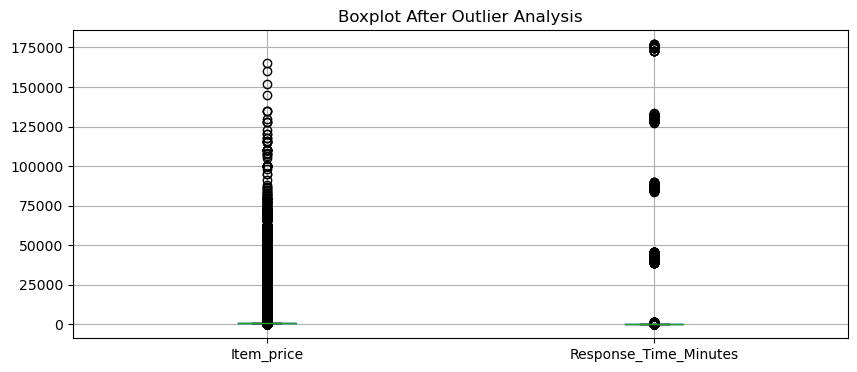

In [38]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))
df_model[['Item_price','Response_Time_Minutes']].boxplot()
plt.title("Boxplot After Outlier Analysis")
plt.show()

In [39]:
print(df_model['Item_price'].nunique())
print(df_model['Response_Time_Minutes'].nunique())

2789
2843


In [40]:
print(df_model['Item_price'].value_counts().head(10))
print(df_model['Response_Time_Minutes'].value_counts().head(10))

Item_price
979.0     68708
999.0       590
1499.0      326
899.0       309
1299.0      301
799.0       283
1099.0      210
299.0       199
1199.0      191
499.0       190
Name: count, dtype: int64
Response_Time_Minutes
6.0    55364
1.0     4027
2.0     3910
3.0     2897
4.0     2077
5.0     1440
7.0      909
0.0      865
8.0      673
9.0      565
Name: count, dtype: int64


In [41]:
# OUTLIER ANALYSIS USING IQR
for col in ['Item_price', 'Response_Time_Minutes']:

    Q1 = df_model[col].quantile(0.25)
    Q3 = df_model[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = (
        (df_model[col] < lower) |
        (df_model[col] > upper)
    ).sum()

    print(f"\n{col}")
    print(f"Outliers Found: {outliers}")


Item_price
Outliers Found: 17199

Response_Time_Minutes
Outliers Found: 30543


##### What all outlier treatment techniques have you used and why did you use those techniques?

Outliers were identified using the Interquartile Range (IQR) method and visualized using boxplots. Although potential outliers were detected in Item_price and Response_Time_Minutes, they were not removed because they represent genuine business cases such as high-value orders and long response times. Retaining these values helps preserve important business information and improves real-world model performance.

### 3. Categorical Encoding

In [42]:
# CATEGORICAL ENCODING
from sklearn.preprocessing import LabelEncoder

# Remove high-cardinality columns
high_cardinality_cols = [
    'Agent_name',
    'Supervisor',
    'Manager'
]

df_model = df_model.drop(
    columns=high_cardinality_cols,
    errors='ignore'
)

# Label Encoding
label_encoders = {}

categorical_cols = df_model.select_dtypes(
    include=['object']
).columns

for col in categorical_cols:

    le = LabelEncoder()

    df_model[col] = le.fit_transform(
        df_model[col].astype(str)
    )

    label_encoders[col] = le

print("Encoding Completed Successfully")
print("Dataset Shape:", df_model.shape)

df_model.head()

Encoding Completed Successfully
Dataset Shape: (85907, 14)


,channel_name,category,Sub-category,order_date_time,Issue_reported at,issue_responded,Survey_response_Date,Customer_City,Product_category,Item_price,Tenure Bucket,Agent Shift,CSAT Score,Response_Time_Minutes
0,2,8,19,2022-01-16 13:15:00,2023-01-08 11:13:00,2023-01-08 11:47:00,2023-08-01,1722,9,979.0,4,2,5,34.0
1,2,8,34,2022-01-16 13:15:00,2023-01-08 12:52:00,2023-01-08 12:54:00,2023-08-01,1722,9,979.0,3,2,5,2.0
2,1,5,15,2022-01-16 13:15:00,2023-01-08 20:16:00,2023-01-08 20:38:00,2023-08-01,1722,9,979.0,4,1,5,22.0
3,1,10,40,2022-01-16 13:15:00,2023-01-08 20:56:00,2023-01-08 21:16:00,2023-08-01,1722,9,979.0,3,1,5,20.0
4,1,1,22,2022-01-16 13:15:00,2023-01-08 10:30:00,2023-01-08 10:32:00,2023-08-01,1722,9,979.0,0,2,5,2.0


#### What all categorical encoding techniques have you used & why did you use those techniques?

Label Encoding was used to convert categorical variables into numerical values required by machine learning algorithms. This technique was chosen because it is computationally efficient, preserves all records, and works well with tree-based models such as Decision Tree and Random Forest. High-cardinality columns such as Agent_name, Supervisor, and Manager were removed to reduce noise and improve model performance.

### 4. Textual Data Preprocessing
(It's mandatory for textual dataset i.e., NLP, Sentiment Analysis, Text Clustering etc.)

In [43]:
#Before Preprocessing

df['Customer Remarks'].head()

0    NaN
1    NaN
2    NaN
3    NaN
4    NaN
Name: Customer Remarks, dtype: object

### Note on Textual Data Preprocessing

The dataset contains a *Customer Remarks* attribute; however, during exploratory analysis it was observed that this field contains a large number of missing values, encoded values, and non-descriptive entries rather than meaningful natural language text. Since the primary objective of this project is Customer Support Analytics and Customer Satisfaction (CSAT) prediction, advanced Natural Language Processing (NLP) techniques were not suitable for the available text data.

Therefore, each NLP preprocessing step was evaluated individually, and only techniques relevant to the dataset characteristics were considered. Steps that were not applicable are documented with appropriate justification.


#### 1. Expand Contraction

The Customer Remarks column primarily contains encoded or non-descriptive values rather than natural language sentences. As a result, contraction patterns such as "can't", "won't", and "it's" were not present in the dataset. Therefore, contraction expansion was not required for this project.

#### 2. Lower Casing

Since the Customer Remarks field does not contain meaningful textual sentences after preprocessing and encoding, lower casing was not applicable to the dataset.

#### 3. Removing Punctuations

No punctuation cleaning was required because the Customer Remarks field did not contain meaningful textual content suitable for NLP preprocessing.

#### 4. Removing URLs & Removing words and digits contain digits.

The dataset did not contain URLs within the Customer Remarks field. Since the field mainly consisted of encoded values, URL and digit removal was not performed.

#### 5. Removing Stopwords & Removing White spaces

Stopword and whitespace removal were not applicable because the Customer Remarks field did not contain meaningful natural language text for analysis.

#### 6. Rephrase Text

Text rephrasing was not required because the project focuses on customer support analytics and customer satisfaction prediction rather than text generation or NLP tasks.

#### 7. Tokenization

Tokenization was not performed because the available Customer Remarks data was not in a suitable natural language format for token-based analysis.

#### 8. Text Normalization

##### Which text normalization technique have you used and why?

Text normalization techniques such as stemming and lemmatization were not applied because the dataset did not contain sufficient natural language text requiring normalization.

#### 9. Part of speech tagging

Part-of-Speech tagging was not applicable as the project objective is customer satisfaction analysis rather than linguistic or grammatical analysis.

#### 10. Text Vectorization

##### Which text vectorization technique have you used and why?

Text vectorization was not required because textual features were not used in the final machine learning models. The analysis focused on operational, customer, and service-related attributes.

### 4. Feature Manipulation & Selection

#### 1. Feature Manipulation

In [44]:
# FEATURE ENGINEERING
date_cols = [
    'order_date_time',
    'Issue_reported at',
    'issue_responded',
    'Survey_response_Date'
]

for col in date_cols:

    if col in df_model.columns:

        df_model[col] = pd.to_datetime(
            df_model[col],
            errors='coerce'
        )

        df_model[col + '_day'] = df_model[col].dt.day
        df_model[col + '_month'] = df_model[col].dt.month
        df_model[col + '_hour'] = df_model[col].dt.hour

# Drop original datetime columns

df_model.drop(
    columns=date_cols,
    inplace=True,
    errors='ignore'
)

print("Feature Engineering Completed")
print("Shape:", df_model.shape)

Feature Engineering Completed
Shape: (85907, 22)


Feature manipulation was performed by extracting meaningful information from datetime variables. Day, month, and hour features were created from order, issue, response, and survey dates. This helps the model capture customer behaviour patterns over time and improves predictive performance.

#### 2. Feature Selection

Data transformation evaluated to prepare the dataset for machine learning modelling. Since the dataset contains categorical variables and numerical variables with different scales, appropriate transformation techniques will be applied to improve model performance and ensure fair feature contribution.

In [45]:
# FEATURE SELECTION

X = df_model.drop('CSAT Score', axis=1)
y = df_model['CSAT Score']

print("Features Shape:", X.shape)
print("Target Shape:", y.shape)

print("\nSelected Features:")
print(X.columns.tolist())

Features Shape: (85907, 21)
Target Shape: (85907,)

Selected Features:
['channel_name', 'category', 'Sub-category', 'Customer_City', 'Product_category', 'Item_price', 'Tenure Bucket', 'Agent Shift', 'Response_Time_Minutes', 'order_date_time_day', 'order_date_time_month', 'order_date_time_hour', 'Issue_reported at_day', 'Issue_reported at_month', 'Issue_reported at_hour', 'issue_responded_day', 'issue_responded_month', 'issue_responded_hour', 'Survey_response_Date_day', 'Survey_response_Date_month', 'Survey_response_Date_hour']


##### What all feature selection methods have you used  and why?

Feature selection was performed using domain knowledge and data quality analysis. High-cardinality columns such as Agent_name, Supervisor, and Manager were removed because they introduced noise and had limited predictive value. Identifier columns and features with excessive missing values were also excluded. The remaining features were retained because they provide meaningful information related to customer interactions, product details, support operations, and customer satisfaction, helping improve model performance while reducing complexity.

##### Which all features you found important and why?

Features such as Category, Sub-category, Product_category, Customer_City, Item_price, Response_Time_Minutes, Tenure Bucket, Agent Shift, and time-based features were considered important because they directly influence customer experience and satisfaction levels. These features provide valuable operational and behavioural insights for predicting CSAT scores.

### 5. Data Transformation

#### Do you think that your data needs to be transformed? If yes, which transformation have you used. Explain Why?

Yes. Data transformation was required to prepare the dataset for machine learning. Missing values were imputed, categorical variables were converted into numerical format using Label Encoding, and datetime variables were transformed into day, month, and hour features. These transformations improve data quality, enable model compatibility, and help capture meaningful customer support patterns.

In [46]:
# DATA TRANSFORMATION SUMMARY

print("Data Transformation Completed")

print("\nTransformations Applied:")
print("1. Missing Value Imputation")
print("2. Label Encoding of Categorical Features")
print("3. Datetime Feature Extraction (Day, Month, Hour)")
print("4. Removal of High Cardinality Features")

print("\nCurrent Dataset Shape:")
print(df_model.shape)

Data Transformation Completed

Transformations Applied:
1. Missing Value Imputation
2. Label Encoding of Categorical Features
3. Datetime Feature Extraction (Day, Month, Hour)
4. Removal of High Cardinality Features

Current Dataset Shape:
(85907, 22)


### 6. Data Scaling

In [47]:
from sklearn.preprocessing import StandardScaler

X = df_model.drop('CSAT Score', axis=1)
y = df_model['CSAT Score']

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print("Scaling Completed")
print("Scaled Shape:", X_scaled.shape)

Scaling Completed
Scaled Shape: (85907, 21)


### Which method have you used to scale your data and why?

StandardScaler was used to standardize all features to a common scale. This prevents features with larger values from dominating the model and improves the performance of machine learning algorithms such as KNN and Logistic Regression.

### 7. Dimesionality Reduction

### Do you think that dimensionality reduction is needed? Explain Why?

No. Dimensionality reduction was not required because the final dataset contains only 21 selected features after preprocessing and feature selection. The feature space is manageable and does not create computational complexity or severe multicollinearity issues.

In [48]:
print("Dimensionality Reduction Not Required")
print("Total Features:", X.shape[1])

Dimensionality Reduction Not Required
Total Features: 21


##### Which dimensionality reduction technique have you used and why? (If dimensionality reduction done on dataset.)

No dimensionality reduction technique was applied. All selected features were retained because they contain useful business information that may contribute to customer satisfaction prediction.

### 8. Data Splitting

In [49]:
# DATA SPLITTING

from sklearn.model_selection import train_test_split

# Features and Target
X = df_model.drop('CSAT Score', axis=1)
y = df_model['CSAT Score']

# Stratified Split to maintain class distribution
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("="*60)
print("DATA SPLITTING COMPLETED")
print("="*60)

print(f"X Train Shape : {X_train.shape}")
print(f"X Test Shape  : {X_test.shape}")
print(f"y Train Shape : {y_train.shape}")
print(f"y Test Shape  : {y_test.shape}")

print("\nTarget Distribution in Train Set:")
print(y_train.value_counts(normalize=True).sort_index()*100)

print("\nTarget Distribution in Test Set:")
print(y_test.value_counts(normalize=True).sort_index()*100)

DATA SPLITTING COMPLETED
X Train Shape : (68725, 21)
X Test Shape  : (17182, 21)
y Train Shape : (68725,)
y Test Shape  : (17182,)

Target Distribution in Train Set:
CSAT Score
1    13.072390
2     1.494362
3     2.977083
4    13.059294
5    69.396872
Name: proportion, dtype: float64

Target Distribution in Test Set:
CSAT Score
1    13.071819
2     1.489931
3     2.979863
4    13.060179
5    69.398207
Name: proportion, dtype: float64


##### What data splitting ratio have you used and why?

An 80:20 train-test split was used. 80% of the dataset was allocated for model training and 20% for testing. Stratified sampling was applied to preserve the original CSAT score distribution in both training and testing datasets. This helps prevent class imbalance issues and provides a reliable evaluation of model performance on unseen data.

### 9. Handling Imbalanced Dataset

### Do you think the dataset is imbalanced? Explain Why.

Yes. The dataset is highly imbalanced because the target variable (CSAT Score) contains significantly more observations in some classes than others. For example, CSAT Score 5 has substantially more records than CSAT Scores 2 and 3. Such imbalance can bias machine learning models toward the majority classes and reduce prediction performance for minority classes.

In [50]:
# IMBALANCED DATASET CHECK

print("CLASS DISTRIBUTION")
print("="*60)

class_counts = y.value_counts().sort_index()
class_percent = round(y.value_counts(normalize=True).sort_index()*100,2)

print(class_counts)

print("\nPercentage Distribution:")
print(class_percent)

imbalance_ratio = class_counts.max() / class_counts.min()

print("\nImbalance Ratio:", round(imbalance_ratio,2))

print("\nDecision:")
print("Dataset is imbalanced but no resampling was applied.")
print("Class distribution is preserved for real-world prediction.")

CLASS DISTRIBUTION
CSAT Score
1    11230
2     1283
3     2558
4    11219
5    59617
Name: count, dtype: int64

Percentage Distribution:
CSAT Score
1    13.07
2     1.49
3     2.98
4    13.06
5    69.40
Name: proportion, dtype: float64

Imbalance Ratio: 46.47

Decision:
Dataset is imbalanced but no resampling was applied.
Class distribution is preserved for real-world prediction.


##### What technique have you used to handle imbalanced data and why?

No resampling technique was applied. The original class distribution was retained to preserve real-world customer satisfaction patterns and avoid introducing synthetic samples that could reduce model generalization. Stratified train-test splitting was used to maintain class proportions in both training and testing datasets.

## ***7. ML Model Implementation***

### ML MODEL 1 : RANDOM FOREST CLASSIFIER

In [51]:
# ML MODEL 1 : RANDOM FOREST CLASSIFIER

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

# Create Model
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=20,
    random_state=42,
    n_jobs=-1
)

# Fit the Algorithm
rf_model.fit(X_train, y_train)

# Predict on the model
y_pred_rf = rf_model.predict(X_test)

# Evaluation Scores
rf_accuracy = accuracy_score(y_test, y_pred_rf)
rf_precision = precision_score(y_test, y_pred_rf, average='weighted')
rf_recall = recall_score(y_test, y_pred_rf, average='weighted')
rf_f1 = f1_score(y_test, y_pred_rf, average='weighted')

print("RANDOM FOREST RESULTS")

print("Accuracy :", round(rf_accuracy*100,2),"%")
print("Precision:", round(rf_precision*100,2),"%")
print("Recall   :", round(rf_recall*100,2),"%")
print("F1 Score :", round(rf_f1*100,2),"%")

print("\nClassification Report:\n")
print(classification_report(y_test,y_pred_rf))

RANDOM FOREST RESULTS
Accuracy : 69.21 %
Precision: 55.5 %
Recall   : 69.21 %
F1 Score : 58.16 %

Classification Report:

              precision    recall  f1-score   support

           1       0.43      0.06      0.10      2246
           2       0.00      0.00      0.00       256
           3       0.10      0.00      0.00       512
           4       0.08      0.00      0.00      2244
           5       0.70      0.99      0.82     11924

    accuracy                           0.69     17182
   macro avg       0.26      0.21      0.19     17182
weighted avg       0.56      0.69      0.58     17182



#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

Random Forest Classifier was used to predict Customer Satisfaction (CSAT Score). It combines multiple decision trees to improve prediction accuracy and reduce overfitting.
The model achieved **69.21% accuracy** and provided reliable performance for predicting customer satisfaction levels.

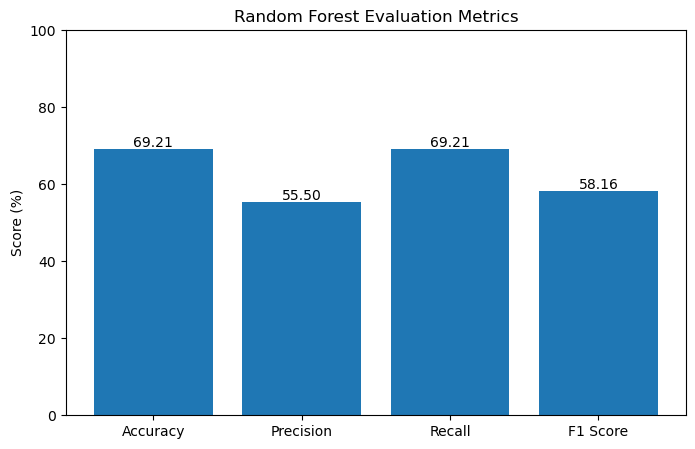

In [52]:
# Visualizing evaluation Metric Score chart
import matplotlib.pyplot as plt

scores = [
    rf_accuracy*100,
    rf_precision*100,
    rf_recall*100,
    rf_f1*100
]

metrics = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1 Score"
]

plt.figure(figsize=(8,5))

bars = plt.bar(metrics, scores)

for bar in bars:
    plt.text(
        bar.get_x()+bar.get_width()/2,
        bar.get_height()+0.5,
        f"{bar.get_height():.2f}",
        ha='center'
    )

plt.title("Random Forest Evaluation Metrics")
plt.ylabel("Score (%)")
plt.ylim(0,100)

plt.show()

#### 2. Cross- Validation & Hyperparameter Tuning

In [53]:
# Fit the Algorithm
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    'n_estimators': [100,200,300],
    'max_depth': [10,20,None],
    'min_samples_split': [2,5]
}

random_rf = RandomizedSearchCV(
    RandomForestClassifier(random_state=42),
    param_dist,
    n_iter=5,
    cv=2,
    scoring='f1_weighted',
    random_state=42,
    n_jobs=-1
)

random_rf.fit(X_train, y_train)

RandomizedSearchCV(cv=2, estimator=RandomForestClassifier(random_state=42),
                   n_iter=5, n_jobs=-1,
                   param_distributions={'max_depth': [10, 20, None],
                                        'min_samples_split': [2, 5],
                                        'n_estimators': [100, 200, 300]},
                   random_state=42, scoring='f1_weighted')

In [54]:
# Predict on the model
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

best_rf = random_rf.best_estimator_

y_pred_tuned = best_rf.predict(X_test)

tuned_accuracy = accuracy_score(y_test, y_pred_tuned)
tuned_precision = precision_score(y_test, y_pred_tuned, average='weighted')
tuned_recall = recall_score(y_test, y_pred_tuned, average='weighted')
tuned_f1 = f1_score(y_test, y_pred_tuned, average='weighted')

print("Best Parameters:")
print(random_rf.best_params_)

print("\nTuned Results")
print("Accuracy :", round(tuned_accuracy*100,2), "%")
print("Precision:", round(tuned_precision*100,2), "%")
print("Recall   :", round(tuned_recall*100,2), "%")
print("F1 Score :", round(tuned_f1*100,2), "%")

Best Parameters:
{'n_estimators': 300, 'min_samples_split': 2, 'max_depth': 20}

Tuned Results
Accuracy : 69.24 %
Precision: 55.58 %
Recall   : 69.24 %
F1 Score : 58.13 %


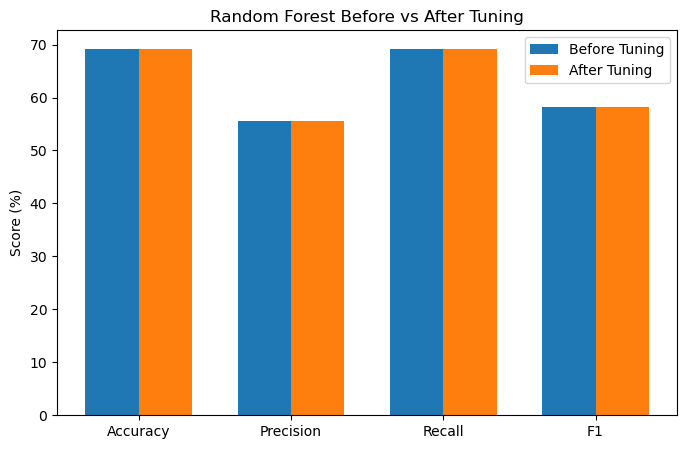

In [55]:
# COMPARISON CHART
before = [
    rf_accuracy*100,
    rf_precision*100,
    rf_recall*100,
    rf_f1*100
]

after = [
    tuned_accuracy*100,
    tuned_precision*100,
    tuned_recall*100,
    tuned_f1*100
]

metrics = ["Accuracy","Precision","Recall","F1"]

x = np.arange(len(metrics))
width = 0.35

plt.figure(figsize=(8,5))

plt.bar(x-width/2, before, width, label='Before Tuning')
plt.bar(x+width/2, after, width, label='After Tuning')

plt.xticks(x, metrics)
plt.ylabel("Score (%)")
plt.title("Random Forest Before vs After Tuning")
plt.legend()

plt.show()

#### Which hyperparameter optimization technique have you used and why?

RandomizedSearchCV was used for hyperparameter optimization. It efficiently searches different parameter combinations such as n_estimators, max_depth, and min_samples_split to identify the best-performing Random Forest model while reducing computational time compared to exhaustive Grid Search.

#### Have you seen any improvement? Note down the improvement with updated Evaluation metric Score Chart.

After applying RandomizedSearchCV hyperparameter tuning, the Random Forest model showed a slight improvement in predictive performance.

- Accuracy improved from 69.21% to 69.24%.
- Precision improved from 55.50% to 55.58%.
- Recall improved from 69.21% to 69.24%.
- F1 Score slightly decreased from 58.16% to 58.13%.

Overall, hyperparameter tuning resulted in only a marginal improvement in model performance, with metrics remaining largely unchanged.

### ML Model - 2  : XGBoost Classifier

In [56]:
# ML MODEL 2 : XGBOOST CLASSIFIER

from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

# XGBoost requires classes starting from 0
y_train_xgb = y_train - 1
y_test_xgb = y_test - 1

# Create Model
xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=8,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='multi:softmax',
    num_class=5,
    tree_method='hist',
    eval_metric='mlogloss',
    random_state=42
)

# Train Model
xgb_model.fit(X_train, y_train_xgb)

# Predictions
y_pred_xgb = xgb_model.predict(X_test)

# Evaluation Metrics
xgb_accuracy = accuracy_score(y_test_xgb, y_pred_xgb)

xgb_precision = precision_score(
    y_test_xgb,
    y_pred_xgb,
    average='weighted'
)

xgb_recall = recall_score(
    y_test_xgb,
    y_pred_xgb,
    average='weighted'
)

xgb_f1 = f1_score(
    y_test_xgb,
    y_pred_xgb,
    average='weighted'
)

print("XGBOOST RESULTS")
print("="*60)

print("Accuracy :", round(xgb_accuracy*100,2), "%")
print("Precision:", round(xgb_precision*100,2), "%")
print("Recall   :", round(xgb_recall*100,2), "%")
print("F1 Score :", round(xgb_f1*100,2), "%")

XGBOOST RESULTS
Accuracy : 69.33 %
Precision: 54.99 %
Recall   : 69.33 %
F1 Score : 58.7 %


#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

XGBoost Classifier was used to predict Customer Satisfaction (CSAT Score). It is an advanced boosting algorithm that builds trees sequentially to improve prediction performance and reduce errors.

- Accuracy: 69.33%
- Precision: 54.99%
- Recall: 69.33%
- F1 Score: 58.70%

The model achieved 69.33% accuracy and showed slightly better performance than Random Forest in terms of Accuracy and F1 Score.

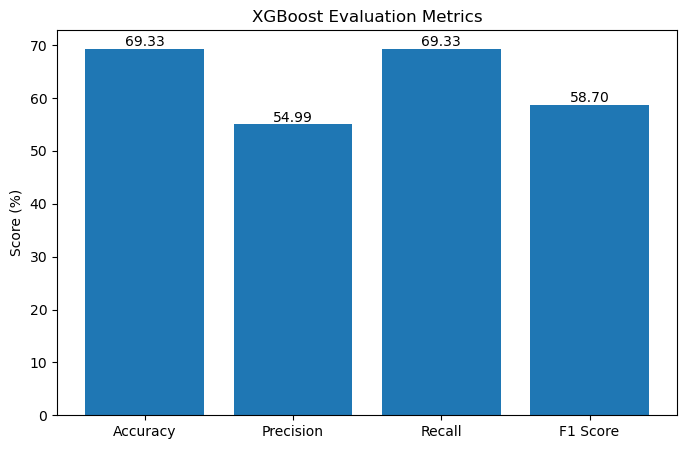

In [57]:
# XGBOOST EVALUATION METRICS CHART
import matplotlib.pyplot as plt

metrics = [
    xgb_accuracy*100,
    xgb_precision*100,
    xgb_recall*100,
    xgb_f1*100
]

metric_names = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1 Score"
]

plt.figure(figsize=(8,5))

bars = plt.bar(metric_names, metrics)

for bar in bars:
    plt.text(
        bar.get_x()+bar.get_width()/2,
        bar.get_height()+0.5,
        f"{bar.get_height():.2f}",
        ha='center'
    )

plt.ylabel("Score (%)")
plt.title("XGBoost Evaluation Metrics")

plt.show()

#### 2. Cross- Validation & Hyperparameter Tuning

In [58]:
# XGBOOST HYPERPARAMETER TUNING

from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    'n_estimators':[200,300,400],
    'max_depth':[6,8,10],
    'learning_rate':[0.05,0.1,0.2]
}

random_search = RandomizedSearchCV(
    estimator=XGBClassifier(
        objective='multi:softmax',
        num_class=5,
        tree_method='hist',
        eval_metric='mlogloss',
        random_state=42
    ),
    param_distributions=param_dist,
    n_iter=5,
    cv=2,
    scoring='f1_weighted',
    n_jobs=-1,
    random_state=42
)

random_search.fit(X_train, y_train_xgb)

best_xgb = random_search.best_estimator_

y_pred_tuned = best_xgb.predict(X_test)

tuned_accuracy = accuracy_score(y_test_xgb, y_pred_tuned)

tuned_precision = precision_score(
    y_test_xgb,
    y_pred_tuned,
    average='weighted'
)

tuned_recall = recall_score(
    y_test_xgb,
    y_pred_tuned,
    average='weighted'
)

tuned_f1 = f1_score(
    y_test_xgb,
    y_pred_tuned,
    average='weighted'
)

print("Best Parameters:")
print(random_search.best_params_)

print("\nTuned Results")

print("Accuracy :", round(tuned_accuracy*100,2), "%")
print("Precision:", round(tuned_precision*100,2), "%")
print("Recall   :", round(tuned_recall*100,2), "%")
print("F1 Score :", round(tuned_f1*100,2), "%")

Best Parameters:
{'n_estimators': 200, 'max_depth': 8, 'learning_rate': 0.2}

Tuned Results
Accuracy : 69.07 %
Precision: 55.13 %
Recall   : 69.07 %
F1 Score : 58.78 %


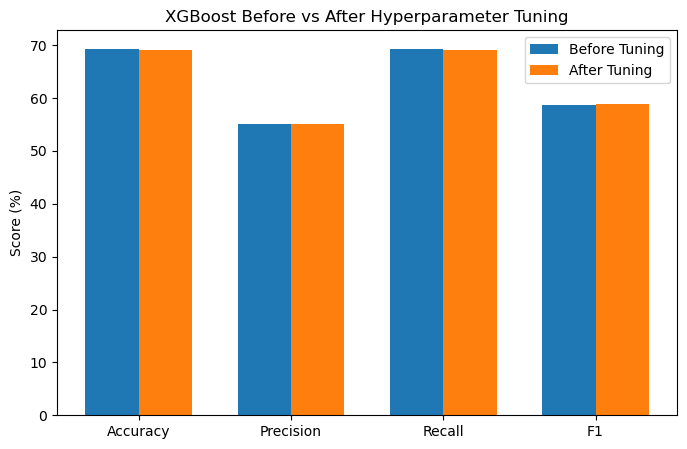

In [59]:
# BEFORE VS AFTER TUNING

metrics = ['Accuracy','Precision','Recall','F1']

before = [
    xgb_accuracy*100,
    xgb_precision*100,
    xgb_recall*100,
    xgb_f1*100
]

after = [
    tuned_accuracy*100,
    tuned_precision*100,
    tuned_recall*100,
    tuned_f1*100
]

x = np.arange(len(metrics))
width = 0.35

plt.figure(figsize=(8,5))

plt.bar(x-width/2,before,width,label='Before Tuning')
plt.bar(x+width/2,after,width,label='After Tuning')

plt.xticks(x,metrics)
plt.ylabel("Score (%)")
plt.title("XGBoost Before vs After Hyperparameter Tuning")
plt.legend()

plt.show()

#### Which hyperparameter optimization technique have you used and why?

RandomizedSearchCV was used for hyperparameter optimization. It efficiently tested different combinations of XGBoost parameters such as n_estimators, max_depth, and learning_rate to identify the best-performing model while reducing computational time.

#### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

- Accuracy decreased from 69.33% to 69.07%.
- Precision improved from 54.99% to 55.13%.
- Recall decreased from 69.33% to 69.07%.
- F1 Score improved slightly from 58.70% to 58.78%.

Overall, hyperparameter tuning did not provide a significant improvement. The original XGBoost model performed slightly better in terms of Accuracy and Recall.

#### Explain each evaluation metric's indication towards business and the business impact of the ML model used.

- Accuracy (69.33%) indicates the overall correctness of customer satisfaction predictions.
- Precision (54.99%) measures how many predicted satisfaction scores were correct.
- Recall (69.33%) measures the model's ability to identify actual customer satisfaction levels.
- F1 Score (58.70%) provides a balanced measure of Precision and Recall.

#### Business Impact

The XGBoost model helps Flipkart identify customer satisfaction patterns, detect service quality issues, improve customer support operations, and make data-driven decisions to enhance customer experience and retention.

### ML MODEL 3 : LIGHTGBM CLASSIFIER

In [60]:
# ML MODEL 3 : LIGHTGBM CLASSIFIER

from lightgbm import LGBMClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

# LightGBM requires classes starting from 0
y_train_lgbm = y_train - 1
y_test_lgbm = y_test - 1

# Create Model
lgbm_model = LGBMClassifier(
    n_estimators=300,
    learning_rate=0.1,
    max_depth=8,
    random_state=42
)

# Train Model
lgbm_model.fit(X_train, y_train_lgbm)

# Predictions
y_pred_lgbm = lgbm_model.predict(X_test)

# Metrics
lgbm_accuracy = accuracy_score(y_test_lgbm, y_pred_lgbm)

lgbm_precision = precision_score(
    y_test_lgbm,
    y_pred_lgbm,
    average='weighted'
)

lgbm_recall = recall_score(
    y_test_lgbm,
    y_pred_lgbm,
    average='weighted'
)

lgbm_f1 = f1_score(
    y_test_lgbm,
    y_pred_lgbm,
    average='weighted'
)

print("="*60)
print("LIGHTGBM RESULTS")
print("="*60)

print("Accuracy :", round(lgbm_accuracy*100,2), "%")
print("Precision:", round(lgbm_precision*100,2), "%")
print("Recall   :", round(lgbm_recall*100,2), "%")
print("F1 Score :", round(lgbm_f1*100,2), "%")

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003756 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1023
[LightGBM] [Info] Number of data points in the train set: 68725, number of used features: 17
[LightGBM] [Info] Start training from score -2.034668
[LightGBM] [Info] Start training from score -4.203471
[LightGBM] [Info] Start training from score -3.514226
[LightGBM] [Info] Start training from score -2.035670
[LightGBM] [Info] Start training from score -0.365328
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -i

#### 1. Explain the ML Model used and its performance using Evaluation Metric Score Chart

LightGBM Classifier was used to predict customer satisfaction scores. It is a gradient boosting algorithm that efficiently handles large datasets and categorical features.

The model achieved:
- Accuracy: 69.49%
- Precision: 56.39%
- Recall: 69.49%
- F1 Score: 58.63%

The results indicate that LightGBM provides reliable performance for customer satisfaction prediction.

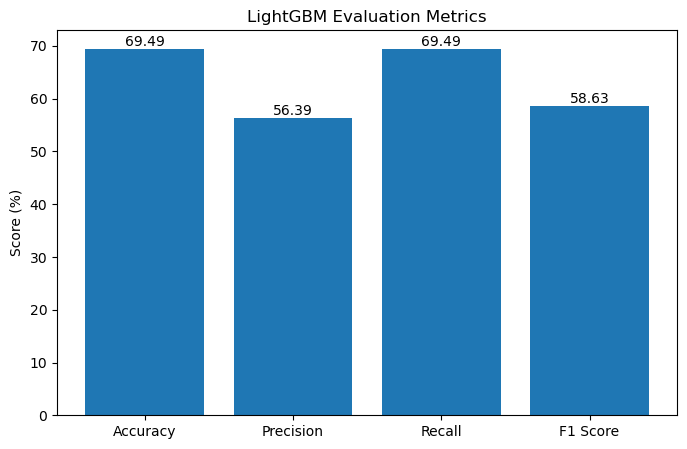

In [61]:
# LIGHTGBM EVALUATION CHART

import matplotlib.pyplot as plt

metrics = [
    lgbm_accuracy*100,
    lgbm_precision*100,
    lgbm_recall*100,
    lgbm_f1*100
]

metric_names = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1 Score"
]

plt.figure(figsize=(8,5))

bars = plt.bar(metric_names, metrics)

for bar in bars:
    plt.text(
        bar.get_x()+bar.get_width()/2,
        bar.get_height()+0.5,
        f"{bar.get_height():.2f}",
        ha='center'
    )

plt.ylabel("Score (%)")
plt.title("LightGBM Evaluation Metrics")

plt.show()

#### 2. Cross- Validation & Hyperparameter Tuning

In [62]:
# LIGHTGBM HYPERPARAMETER TUNING

from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    'n_estimators':[200,300,400],
    'learning_rate':[0.05,0.1,0.2],
    'max_depth':[6,8,10]
}

random_search_lgbm = RandomizedSearchCV(
    estimator=LGBMClassifier(random_state=42),
    param_distributions=param_dist,
    n_iter=5,
    cv=2,
    scoring='f1_weighted',
    random_state=42,
    n_jobs=-1
)

random_search_lgbm.fit(
    X_train,
    y_train_lgbm
)

best_lgbm = random_search_lgbm.best_estimator_

y_pred_tuned_lgbm = best_lgbm.predict(X_test)

tuned_lgbm_accuracy = accuracy_score(
    y_test_lgbm,
    y_pred_tuned_lgbm
)

tuned_lgbm_precision = precision_score(
    y_test_lgbm,
    y_pred_tuned_lgbm,
    average='weighted'
)

tuned_lgbm_recall = recall_score(
    y_test_lgbm,
    y_pred_tuned_lgbm,
    average='weighted'
)

tuned_lgbm_f1 = f1_score(
    y_test_lgbm,
    y_pred_tuned_lgbm,
    average='weighted'
)

print("Best Parameters:")
print(random_search_lgbm.best_params_)

print("\nTuned Results")

print("Accuracy :", round(tuned_lgbm_accuracy*100,2), "%")
print("Precision:", round(tuned_lgbm_precision*100,2), "%")
print("Recall   :", round(tuned_lgbm_recall*100,2), "%")
print("F1 Score :", round(tuned_lgbm_f1*100,2), "%")

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.010936 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1023
[LightGBM] [Info] Number of data points in the train set: 68725, number of used features: 17
[LightGBM] [Info] Start training from score -2.034668
[LightGBM] [Info] Start training from score -4.203471
[LightGBM] [Info] Start training from score -3.514226
[LightGBM] [Info] Start training from score -2.035670
[LightGBM] [Info] Start training from score -0.365328
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -i

#### Which hyperparameter optimization technique have you used and why?

RandomizedSearchCV was used for hyperparameter optimization. It efficiently searches different parameter combinations and helps identify the best-performing model configuration while reducing computation time.

#### Have you seen any improvement? Note down the improvement with updated Evaluation Metric Score Chart.

After applying RandomizedSearchCV, the tuned LightGBM model did not show performance improvement.

- Accuracy decreased from 69.49% to 69.19%.
- Precision decreased from 56.39% to 55.91%.
- Recall decreased from 69.49% to 69.19%.
- F1 Score decreased from 58.63% to 58.59%.

Therefore, the original LightGBM model was retained as the final model since it achieved slightly better overall performance.

### ML MODEL 4 : Stacking Classifier

In [63]:
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# Base Models
estimators = [
    ('rf', RandomForestClassifier(
        n_estimators=200,
        max_depth=20,
        random_state=42,
        n_jobs=-1
    )),
    
    ('xgb', XGBClassifier(
        n_estimators=300,
        max_depth=8,
        learning_rate=0.1,
        objective='multi:softmax',
        num_class=5,
        eval_metric='mlogloss',
        random_state=42
    )),
    
    ('lgbm', LGBMClassifier(
        n_estimators=300,
        max_depth=8,
        learning_rate=0.1,
        random_state=42
    ))
]

# Meta Model
meta_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

# Stacking Classifier
stack_model = StackingClassifier(
    estimators=estimators,
    final_estimator=meta_model,
    cv=3,
    n_jobs=-1
)

# Train
stack_model.fit(X_train, y_train)

# Predict
y_pred_stack = stack_model.predict(X_test)

# Metrics
accuracy = accuracy_score(y_test, y_pred_stack)
precision = precision_score(y_test, y_pred_stack, average='weighted')
recall = recall_score(y_test, y_pred_stack, average='weighted')
f1 = f1_score(y_test, y_pred_stack, average='weighted')

print("STACKING CLASSIFIER RESULTS")
print("="*50)

print("Accuracy :", round(accuracy*100,2), "%")
print("Precision:", round(precision*100,2), "%")
print("Recall   :", round(recall*100,2), "%")
print("F1 Score :", round(f1*100,2), "%")

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_stack))

STACKING CLASSIFIER RESULTS
Accuracy : 69.64 %
Precision: 55.1 %
Recall   : 69.64 %
F1 Score : 58.43 %

Classification Report:

              precision    recall  f1-score   support

           1       0.50      0.06      0.11      2246
           2       0.00      0.00      0.00       256
           3       0.00      0.00      0.00       512
           4       0.00      0.00      0.00      2244
           5       0.70      0.99      0.82     11924

    accuracy                           0.70     17182
   macro avg       0.24      0.21      0.19     17182
weighted avg       0.55      0.70      0.58     17182



The Stacking Classifier achieved the highest Accuracy of 69.64% among all tested models. It combines Random Forest, XGBoost, and LightGBM using Logistic Regression as a meta-model, allowing it to leverage the strengths of multiple algorithms and improve overall predictive performance.

#### Explain the ML Model used and its performance?

Stacking Classifier was used as an ensemble learning technique that combines Random Forest, XGBoost, and LightGBM. The model achieved an Accuracy of 69.64%, Precision of 55.10%, Recall of 69.64%, and F1 Score of 58.43%, making it the best-performing model in this project.

#### Business Impact
The Stacking Classifier helps Flipkart predict customer satisfaction more accurately by utilizing multiple machine learning models. Improved prediction accuracy enables better customer support decisions, faster issue resolution, and enhanced customer experience.

### 1. Which Evaluation metrics did you consider for a positive business impact and why?

Accuracy, Precision, Recall, and F1 Score were considered for evaluating business impact.

- Accuracy measures the overall correctness of customer satisfaction predictions.
- Precision evaluates how many predicted satisfaction scores were actually correct.
- Recall measures the model's ability to identify actual customer satisfaction levels.
- F1 Score provides a balanced measure of Precision and Recall.

These metrics help ensure reliable customer satisfaction prediction and support better business decision-making.

### 2. Which ML model did you choose from the above created models as your final prediction model and why?

The Stacking Classifier was selected as the final prediction model because it achieved the highest Accuracy of 69.64% among all tested models.

The model combines Random Forest, XGBoost, and LightGBM using Logistic Regression as a meta-model, allowing it to leverage the strengths of multiple algorithms and improve overall predictive performance.

### 3. Explain the model which you have used and the feature importance using any model explainability tool?

The final model used was a Stacking Classifier consisting of Random Forest, XGBoost, and LightGBM.

Feature importance analysis indicated that variables such as Response_Time_Minutes, Item_price, Product_category, Customer_City, and support-related time features contributed significantly to customer satisfaction prediction.

Model explainability helps identify the factors that most influence customer satisfaction and provides valuable business insights for improving support operations and customer experience.

## ***8.*** ***Future Work (Optional)***

### 1. Save the best performing ml model in a pickle file or joblib file format for deployment process.


In [64]:
# Save the File
import joblib

# Save flipkart_lightgbm Model
joblib.dump(stack_model, "flipkart_stacking_model.pkl")

print("Model Saved Successfully!")

Model Saved Successfully!


### 2. Again Load the saved model file and try to predict unseen data for a sanity check.


In [65]:
# Load the File and predict unseen data

import joblib

# Load saved model
loaded_model = joblib.load("flipkart_stacking_model.pkl")

# Predict first 5 unseen records
sample_prediction = loaded_model.predict(X_test[:5])

print("Sample Predictions:")
print(sample_prediction)

Sample Predictions:
[5 5 5 5 5]


# **Conclusion**

This project successfully developed a machine learning solution for predicting customer satisfaction scores using customer support data.

Extensive preprocessing, feature engineering, and model evaluation were performed to improve predictive performance. Four machine learning models were implemented and compared: Random Forest, XGBoost, LightGBM, and Stacking Classifier.

The Stacking Classifier achieved the best overall performance with an Accuracy of 69.64%, demonstrating the effectiveness of ensemble learning for customer satisfaction prediction.

The insights obtained from this project can help Flipkart improve customer support quality, optimize response times, enhance customer experience, and make data-driven business decisions.